# Частотные графики и матрицы


## 1. Настройки


In [1]:
from pathlib import Path  # удобная работа с путями к папкам и файлам
from concurrent.futures import ProcessPoolExecutor  # параллельный запуск подсчета по статьям
import multiprocessing as mp  # настройка способа запуска процессов на macOS
import os  # узнаем число ядер процессора
import re  # регулярные выражения для поиска терминов в тексте
import textwrap  # перенос длинных подписей на графиках

import fitz  # PyMuPDF: достает текст из PDF-файлов
import numpy as np  # числовые массивы для делений осей в матрицах
import pandas as pd  # таблицы, Excel и CSV
import matplotlib.pyplot as plt  # построение графиков
from IPython.display import display  # показывает готовую картинку прямо в ноутбуке
from tqdm.auto import tqdm  # прогресс-бар для долгих циклов

ARTICLES_DIR = Path("PDF")  # папка с исходными статьями
TEXTS_DIR = Path("texts")  # папка, куда складываем очищенные TXT
FREQ_DIR = Path("frequency_outputs")  # папка для частотных графиков
MATRIX_DIR = Path("matrix_outputs")  # папка для матриц
TABLE_DIR = Path("tables")  # папка для CSV-таблиц
DICT_FILE = Path("term_dictionary.xlsx")  # Excel-словарь терминов
N = min(61, os.cpu_count() or 1)  # сколько процессов можно запустить параллельно

# Создаем рабочие папки, если их еще нет.
for folder in [TEXTS_DIR, FREQ_DIR, MATRIX_DIR, TABLE_DIR]:
    folder.mkdir(exist_ok=True)

# Перед новым запуском удаляем старые графики и CSV, чтобы не смешивать результаты.
for folder in [FREQ_DIR, MATRIX_DIR, TABLE_DIR]:
    for file in folder.glob("*"):
        if file.is_file():
            file.unlink()


## 2. Словарь из Excel


In [2]:
terms = pd.read_excel(DICT_FILE, sheet_name="terms", dtype=str).fillna("")  # читаем Excel-словарь
terms = terms[["level", "label", "aliases"]]  # оставляем только нужные колонки
terms = terms.apply(lambda col: col.str.strip())  # убираем случайные пробелы в ячейках
terms = terms[(terms["level"] != "") & (terms["label"] != "")]  # убираем пустые строки словаря

rows = []  # словарь в простой форме: level, label и regexes для каждого термина
for term in terms.itertuples(index=False):
    regexes = []  # все regex-варианты для одного термина
    aliases = re.split(r";|\n", term.aliases)  # алиасы разделены точкой с запятой или новой строкой

    for alias in aliases:
        alias = alias.strip().lower()  # один вариант написания термина
        if alias:
            regex = re.escape(alias)  # защищаем спецсимволы, чтобы алиас искался как текст
            regex = regex.replace(r"\ ", r"[-\s]+")  # пробел в алиасе может быть пробелом или дефисом
            regex = regex.replace(r"\-", r"[-\s]*")  # дефис в алиасе может отсутствовать
            regex = r"(?<![a-z0-9_])" + regex + r"(?![a-z0-9_])"  # границы слова
            regexes.append(regex)

    rows.append({"level": term.level, "label": term.label, "regexes": regexes})


## 3. TXT для всех статей


In [3]:
def clean(text):
    """Убирает ссылки и лишние пробелы из текста статьи."""
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()


def read_file(file):
    """Читает TXT/XML/HTML как текст, а PDF через PyMuPDF."""
    if file.suffix.lower() == ".pdf":
        with fitz.open(file) as doc:
            return "\n".join(page.get_text("text") for page in doc)
    return file.read_text(encoding="utf-8", errors="ignore")


files = []  # все исходные файлы статей, которые умеем читать
for mask in ["*.txt", "*.pdf", "*.xml", "*.html", "*.htm"]:
    files += list(ARTICLES_DIR.glob(mask))
files = sorted(set(files))  # sorted для стабильного порядка, set убирает повторы

# Очищаем старые TXT перед новой подготовкой.
for file in TEXTS_DIR.glob("*.txt"):
    file.unlink()

# Каждую статью превращаем в один очищенный TXT.
for file in tqdm(files, desc="Подготовка TXT", unit="файл", leave=False):
    text = clean(read_file(file))  # очищенный текст одной статьи
    (TEXTS_DIR / f"{file.stem}.txt").write_text(text, encoding="utf-8")

txt_files = sorted(TEXTS_DIR.glob("*.txt"))  # подготовленные TXT-файлы для анализа
total = len(txt_files)  # общее число статей, нужно для процентов на графиках


Подготовка TXT:   0%|          | 0/801 [00:00<?, ?файл/s]

## 4. Частоты терминов


In [4]:
ALL_TERMS = []  # общий список терминов внутри каждого процесса
TERM = {}  # быстрый доступ к термину по паре (level, label)


def start(rows):
    """Один раз готовит regex-термины внутри каждого параллельного процесса."""
    global ALL_TERMS, TERM

    ALL_TERMS = []
    for row in rows:
        patterns = []  # скомпилированные regex для одного термина
        for regex in row["regexes"]:
            patterns.append(re.compile(regex))

        item = {  # один термин в рабочем виде для поиска по тексту
            "level": row["level"],
            "label": row["label"],
            "patterns": patterns,
        }
        ALL_TERMS.append(item)

    TERM = {}
    for item in ALL_TERMS:
        TERM[(item["level"], item["label"])] = item


def count_file(file):
    """Считает найденные термины в одном TXT-файле."""
    file = Path(file)
    text = clean(file.read_text(encoding="utf-8", errors="ignore").lower())

    found = []  # строки результата для одной статьи
    for term in ALL_TERMS:
        count = 0  # сколько раз найден текущий термин
        for pattern in term["patterns"]:
            count += len(pattern.findall(text))

        if count:
            found.append({
                "article_id": file.stem,
                "level": term["level"],
                "label": term["label"],
                "mention_count": count,
            })

    return found


# Параллельно считаем термины во всех статьях.
with ProcessPoolExecutor(
    max_workers=N,
    initializer=start,
    initargs=(rows,),
    mp_context=mp.get_context("fork"),
) as pool:
    parts = list(tqdm(  # parts = список результатов от всех процессов
        pool.map(count_file, [str(file) for file in txt_files], chunksize=4),
        total=total,
        desc="Подсчет частот",
        unit="статья",
        leave=False,
    ))

hits_list = []  # плоский список всех найденных терминов во всех статьях
for part in parts:
    hits_list += part

hits = pd.DataFrame(hits_list)  # таблица: статья × найденный термин
freq = (  # частотная таблица: сколько статей и упоминаний у каждого термина
    hits.groupby(["level", "label"], as_index=False)
    .agg(article_count=("article_id", "nunique"), mention_count=("mention_count", "sum"))
)
freq["percent_articles"] = 100 * freq["article_count"] / total  # доля статей с термином
freq = freq[["level", "label", "article_count", "percent_articles", "mention_count"]]

hits.to_csv(TABLE_DIR / "article_term_hits.csv", index=False, encoding="utf-8-sig")
freq.to_csv(TABLE_DIR / "all_frequency_counts.csv", index=False, encoding="utf-8-sig")


Подсчет частот:   0%|          | 0/801 [00:00<?, ?статья/s]

## 5. Пары для матриц


In [5]:
SENTENCE = re.compile(r"(?<=[.!?])\s+")  # простое разбиение текста на предложения


def terms_in(sentence, ok_terms):
    """Возвращает термины, которые найдены в одном предложении."""
    found = {}  # level -> набор найденных label

    for key in ok_terms:
        term = TERM[key]
        yes = False  # найден ли этот термин в предложении

        for pattern in term["patterns"]:
            if pattern.search(sentence):
                yes = True
                break

        if yes:
            level, label = key
            if level not in found:
                found[level] = set()
            found[level].add(label)

    return found


def count_pairs(task):
    """Собирает пары терминов в окне из текущего, прошлого и следующего предложения."""
    file, ok_terms = task  # ok_terms = термины, которые вообще есть в этой статье
    file = Path(file)
    text = clean(file.read_text(encoding="utf-8", errors="ignore").lower())

    sentences = []  # предложения статьи после простой фильтрации
    for sentence in SENTENCE.split(text):
        sentence = sentence.strip()
        if len(sentence) > 20:
            sentences.append(sentence)

    by_sentence = []  # найденные термины для каждого предложения
    for sentence in sentences:
        by_sentence.append(terms_in(sentence, ok_terms))

    seen = set()  # уникальные пары терминов внутри одной статьи
    for i in range(len(by_sentence)):
        window = {}  # термины из трех соседних предложений вокруг i

        for j in range(max(0, i - 1), min(len(by_sentence), i + 2)):
            for level, labels in by_sentence[j].items():
                if level not in window:
                    window[level] = set()
                window[level].update(labels)

        methods = window.get("method", set())  # методы в окне
        features = window.get("feature", set())  # признаки в окне
        markers = window.get("marker_artifact", set())  # маркеры-артефакты в окне
        tools = window.get("tool", set())  # инструменты в окне
        metrics = window.get("metric", set())  # метрики в окне

        # Эти пары сразу записаны в той ориентации, в которой строятся матрицы.
        for method in methods:
            for feature in features:
                seen.add(("method", "feature", method, feature))
            for marker in markers:
                seen.add(("method", "marker_artifact", method, marker))
            for tool in tools:
                seen.add(("method", "tool", method, tool))

        for feature in features:
            for marker in markers:
                seen.add(("feature", "marker_artifact", feature, marker))
            for tool in tools:
                seen.add(("feature", "tool", feature, tool))

        for marker in markers:
            for tool in tools:
                seen.add(("marker_artifact", "tool", marker, tool))

        for metric in metrics:
            for marker in markers:
                seen.add(("metric", "marker_artifact", metric, marker))

    out = []  # строки результата для одной статьи
    for row_level, col_level, row, col in seen:
        out.append({
            "row_level": row_level,
            "col_level": col_level,
            "row": row,
            "col": col,
            "article_id": file.stem,
        })

    return out


ok_by_file = {}  # для каждой статьи храним только найденные в ней термины
for article_id, part in hits.groupby("article_id"):
    ok_by_file[article_id] = set(zip(part["level"], part["label"]))

pair_tasks = []  # задания для параллельного подсчета пар
for file in txt_files:
    ok_terms = ok_by_file.get(file.stem, set())  # термины, которые есть в конкретной статье
    if ok_terms:
        pair_tasks.append((str(file), ok_terms))

# Параллельно считаем пары терминов для матриц.
with ProcessPoolExecutor(
    max_workers=N,
    initializer=start,
    initargs=(rows,),
    mp_context=mp.get_context("fork"),
) as pool:
    parts = list(tqdm(  # parts = список результатов по статьям
        pool.map(count_pairs, pair_tasks, chunksize=2),
        total=len(pair_tasks),
        desc="Подсчет пар",
        unit="статья",
        leave=False,
    ))

pair_list = []  # плоский список всех пар из всех статей
for part in parts:
    pair_list += part

pair_hits = pd.DataFrame(pair_list)  # таблица: статья × найденная пара терминов
pairs = (  # итоговая таблица: сколько статей содержит каждую пару
    pair_hits.groupby(["row_level", "col_level", "row", "col"], as_index=False)
    .agg(article_count=("article_id", "nunique"))
)

pair_hits.to_csv(TABLE_DIR / "sentence_window_pair_hits.csv", index=False, encoding="utf-8-sig")
pairs.to_csv(TABLE_DIR / "sentence_window_pairs.csv", index=False, encoding="utf-8-sig")


Подсчет пар:   0%|          | 0/801 [00:00<?, ?статья/s]

## 6. Частотные графики


Частотные графики:   0%|          | 0/5 [00:00<?, ?график/s]

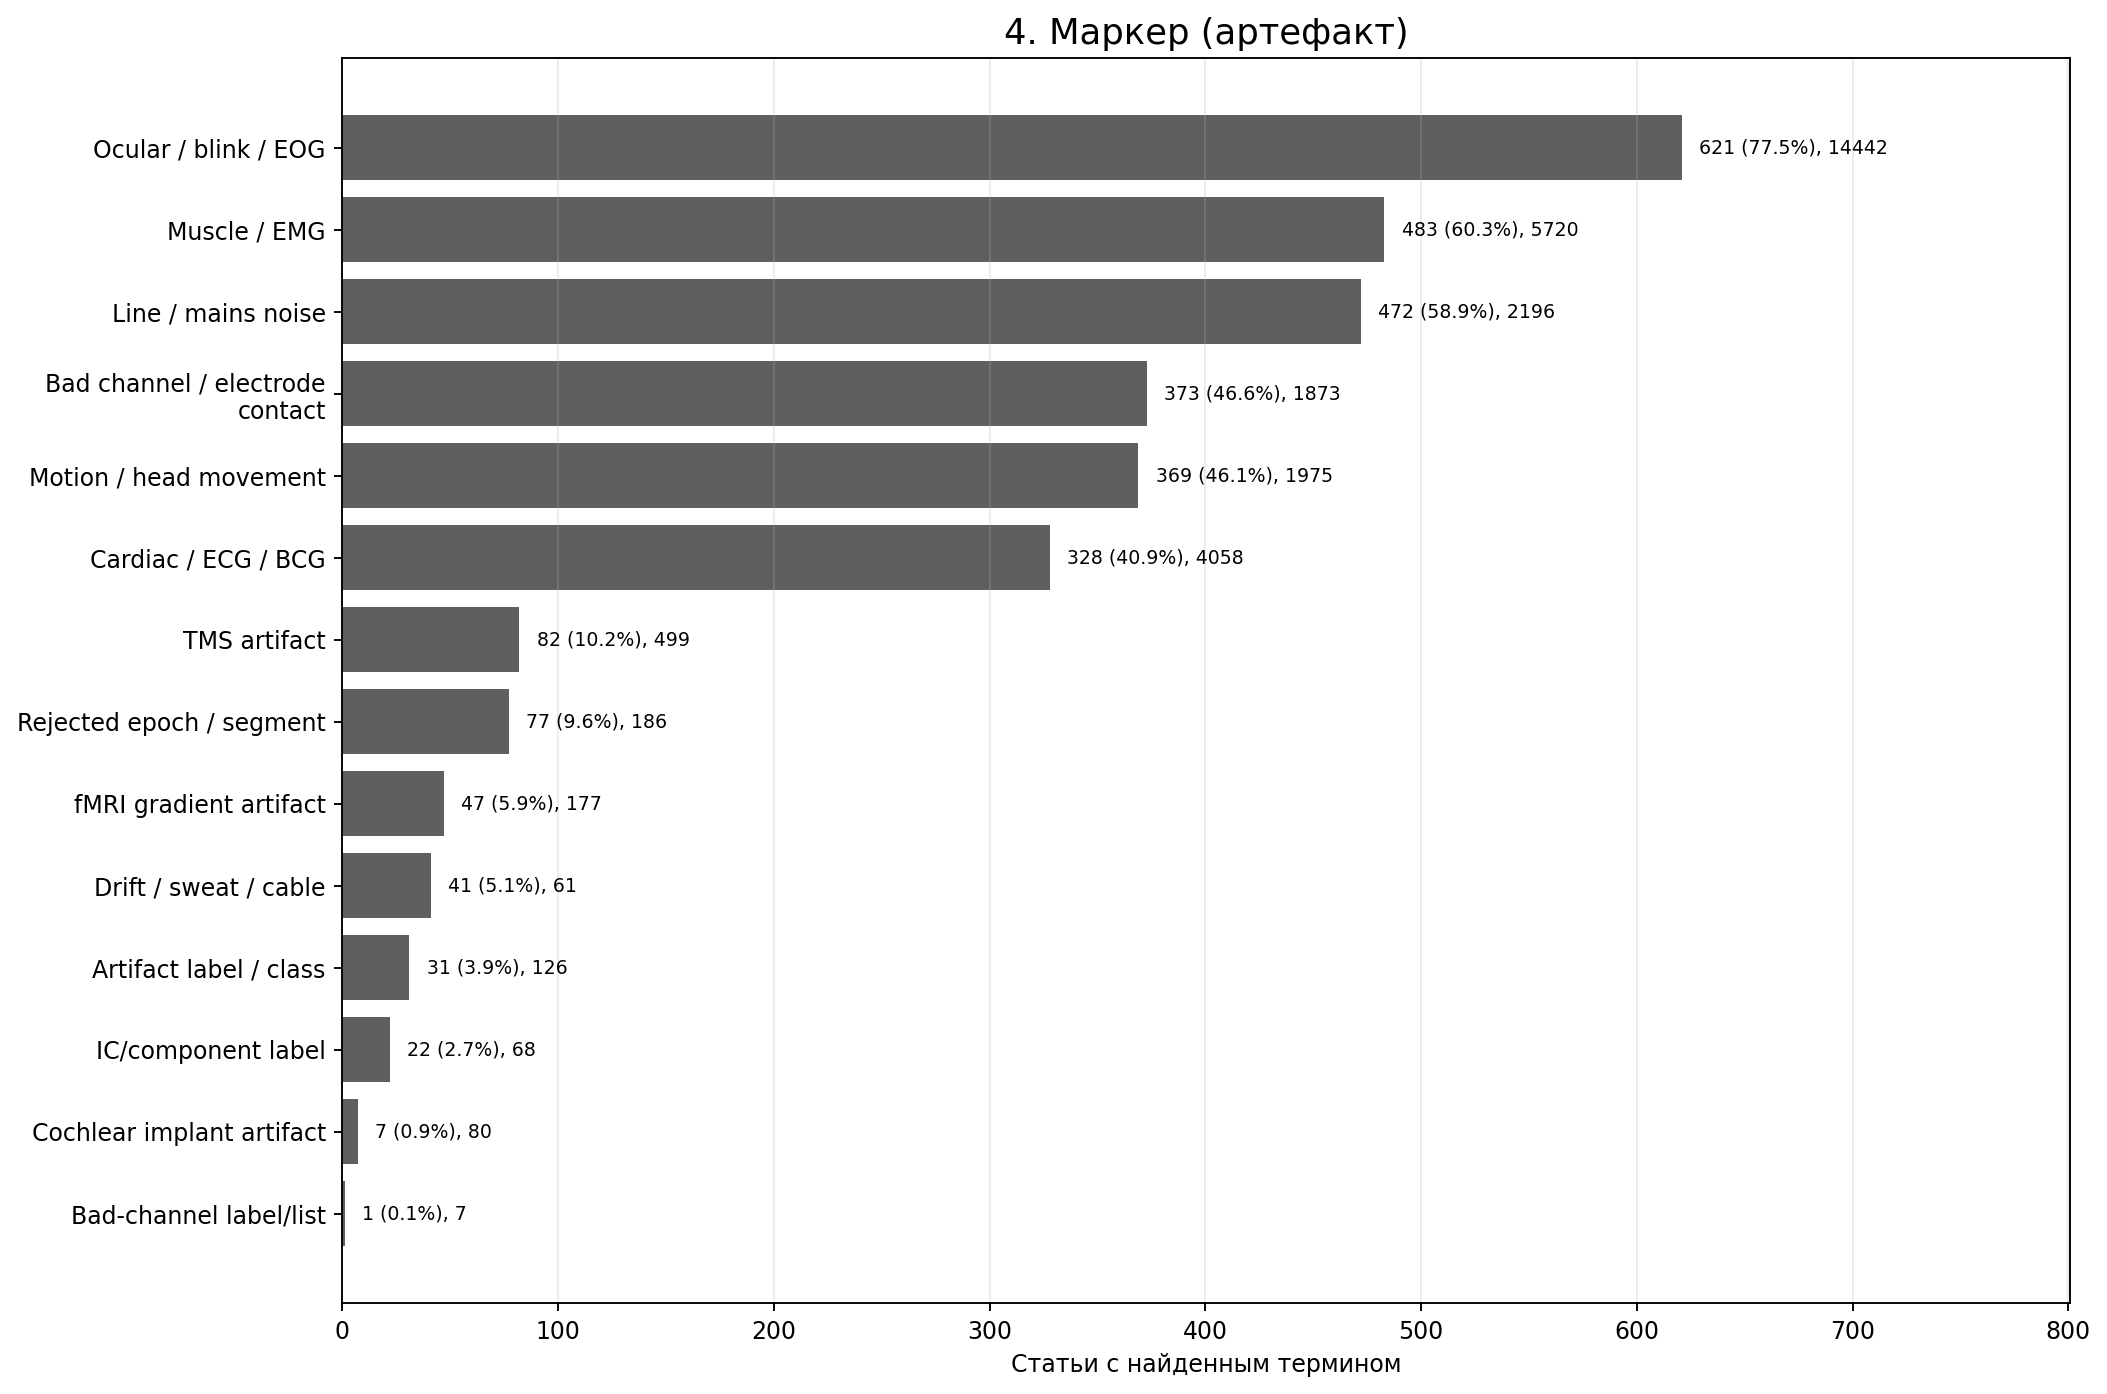

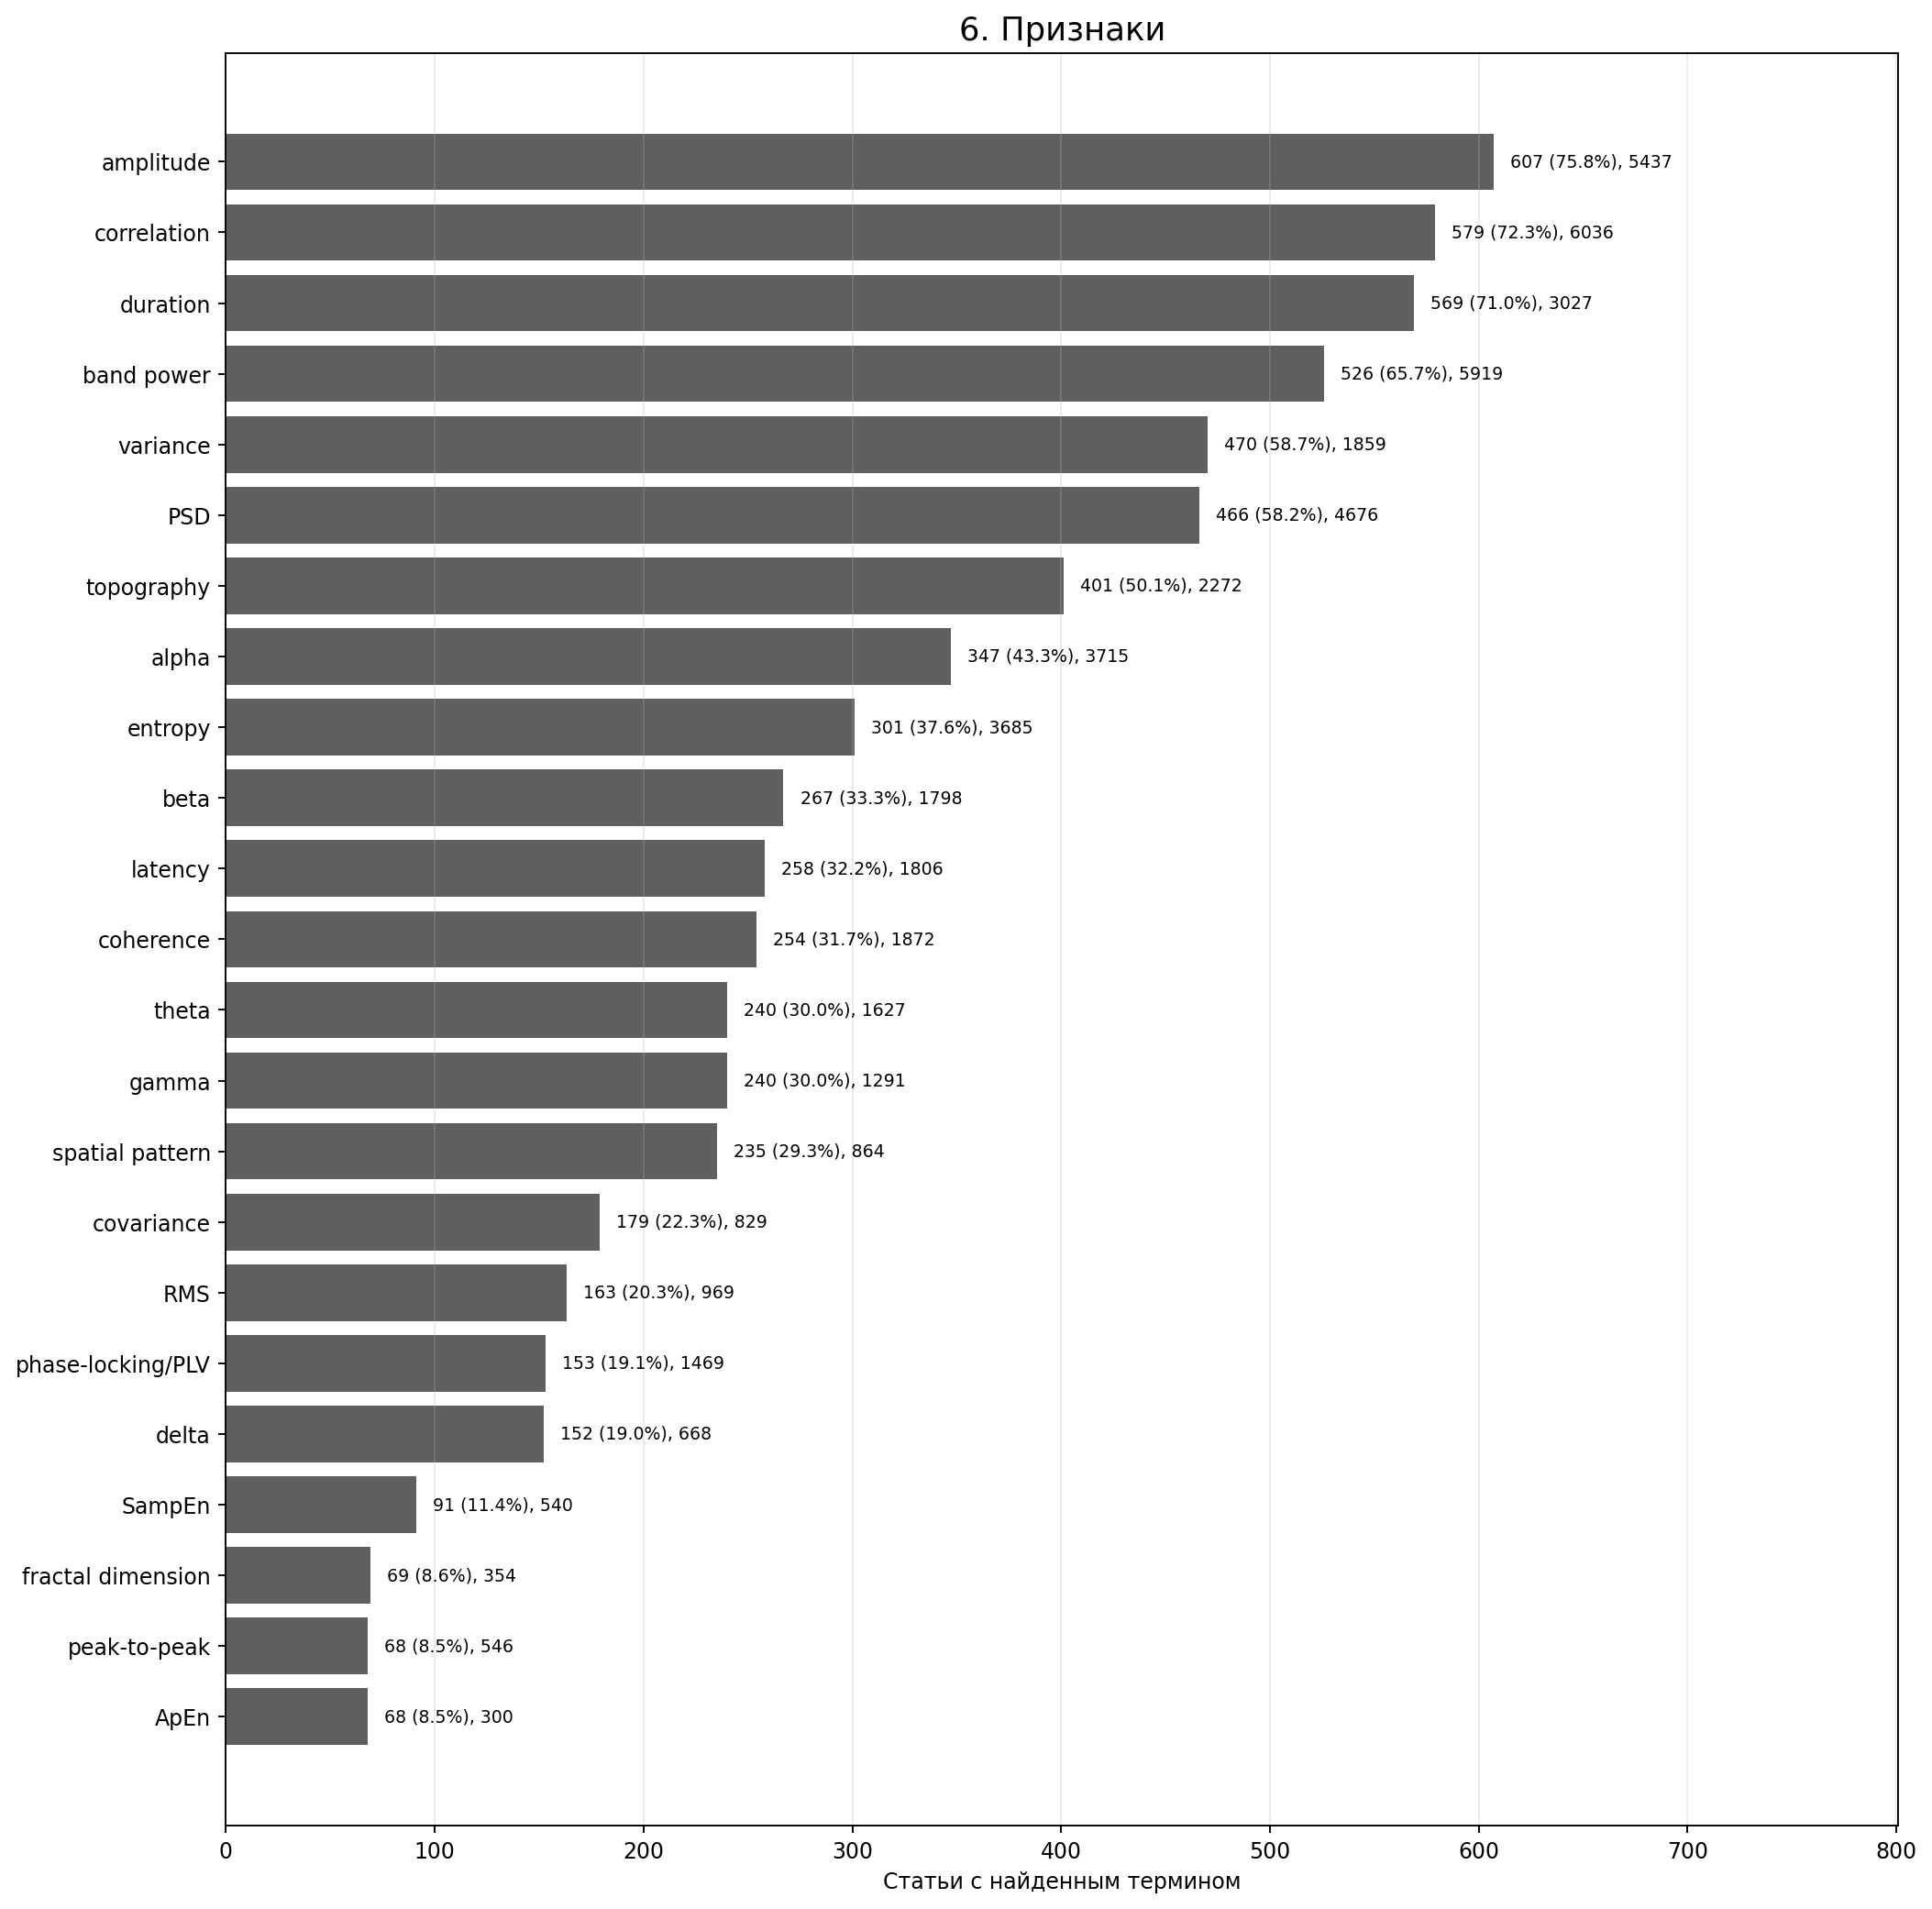

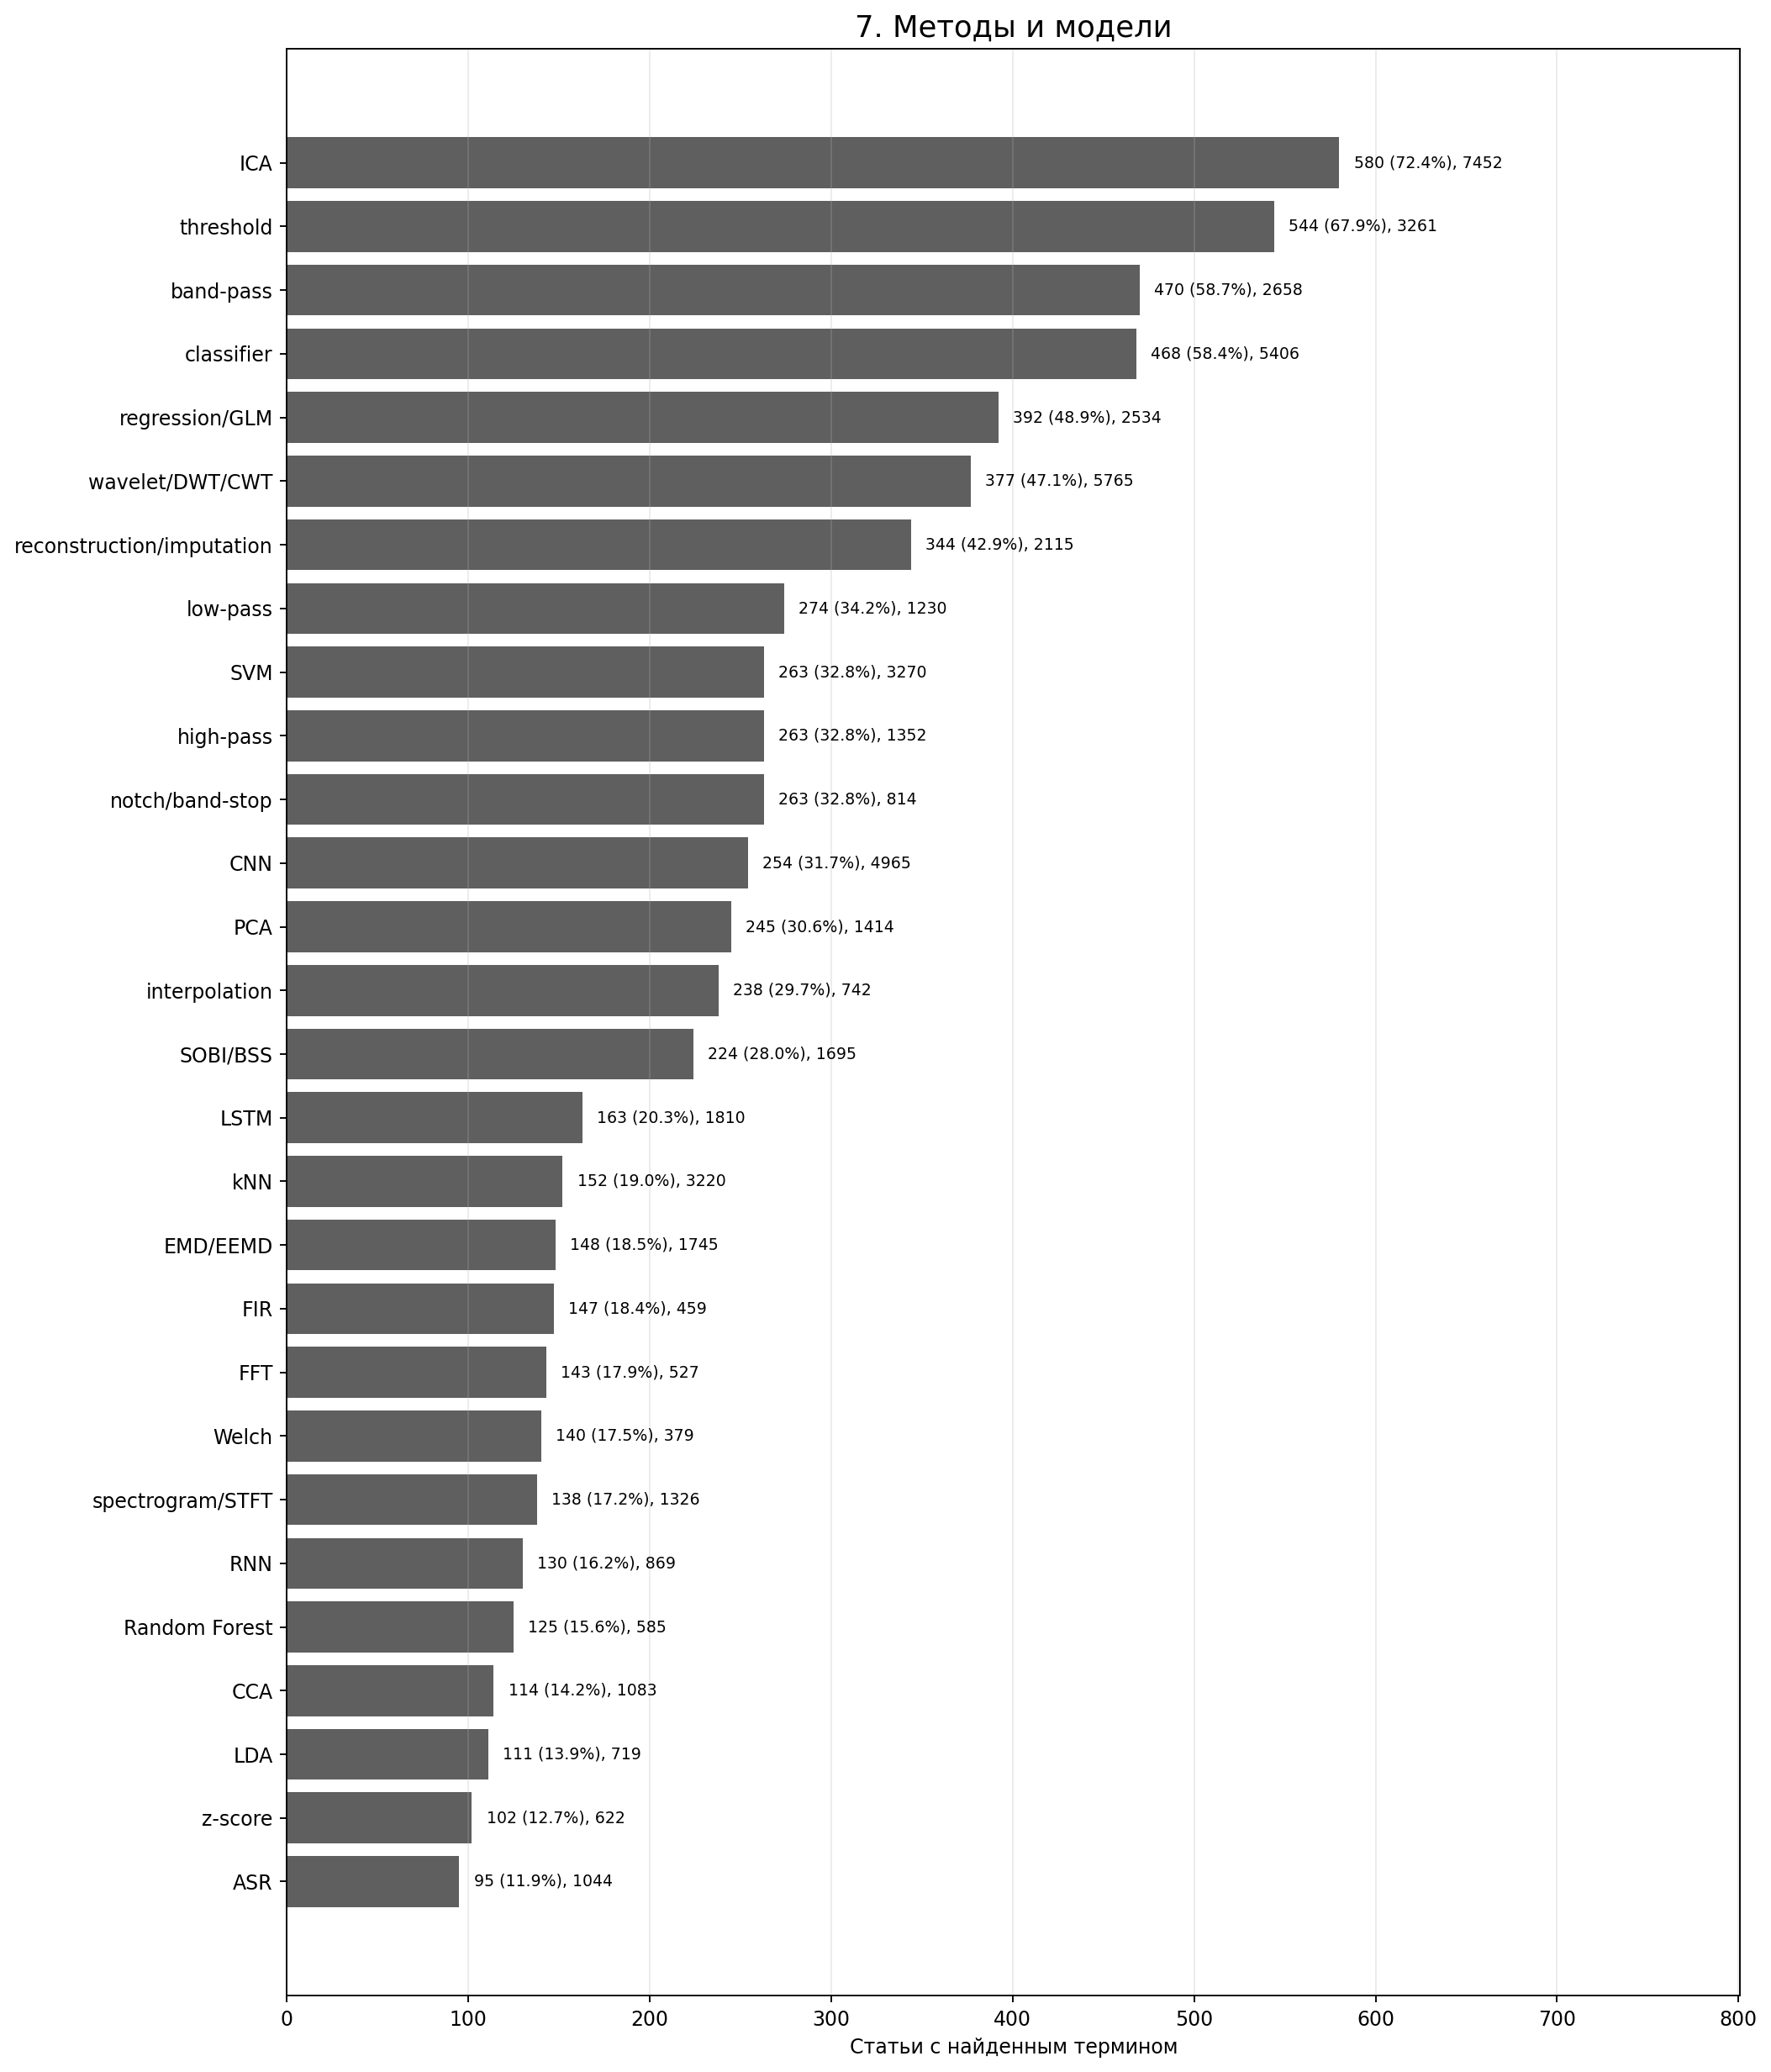

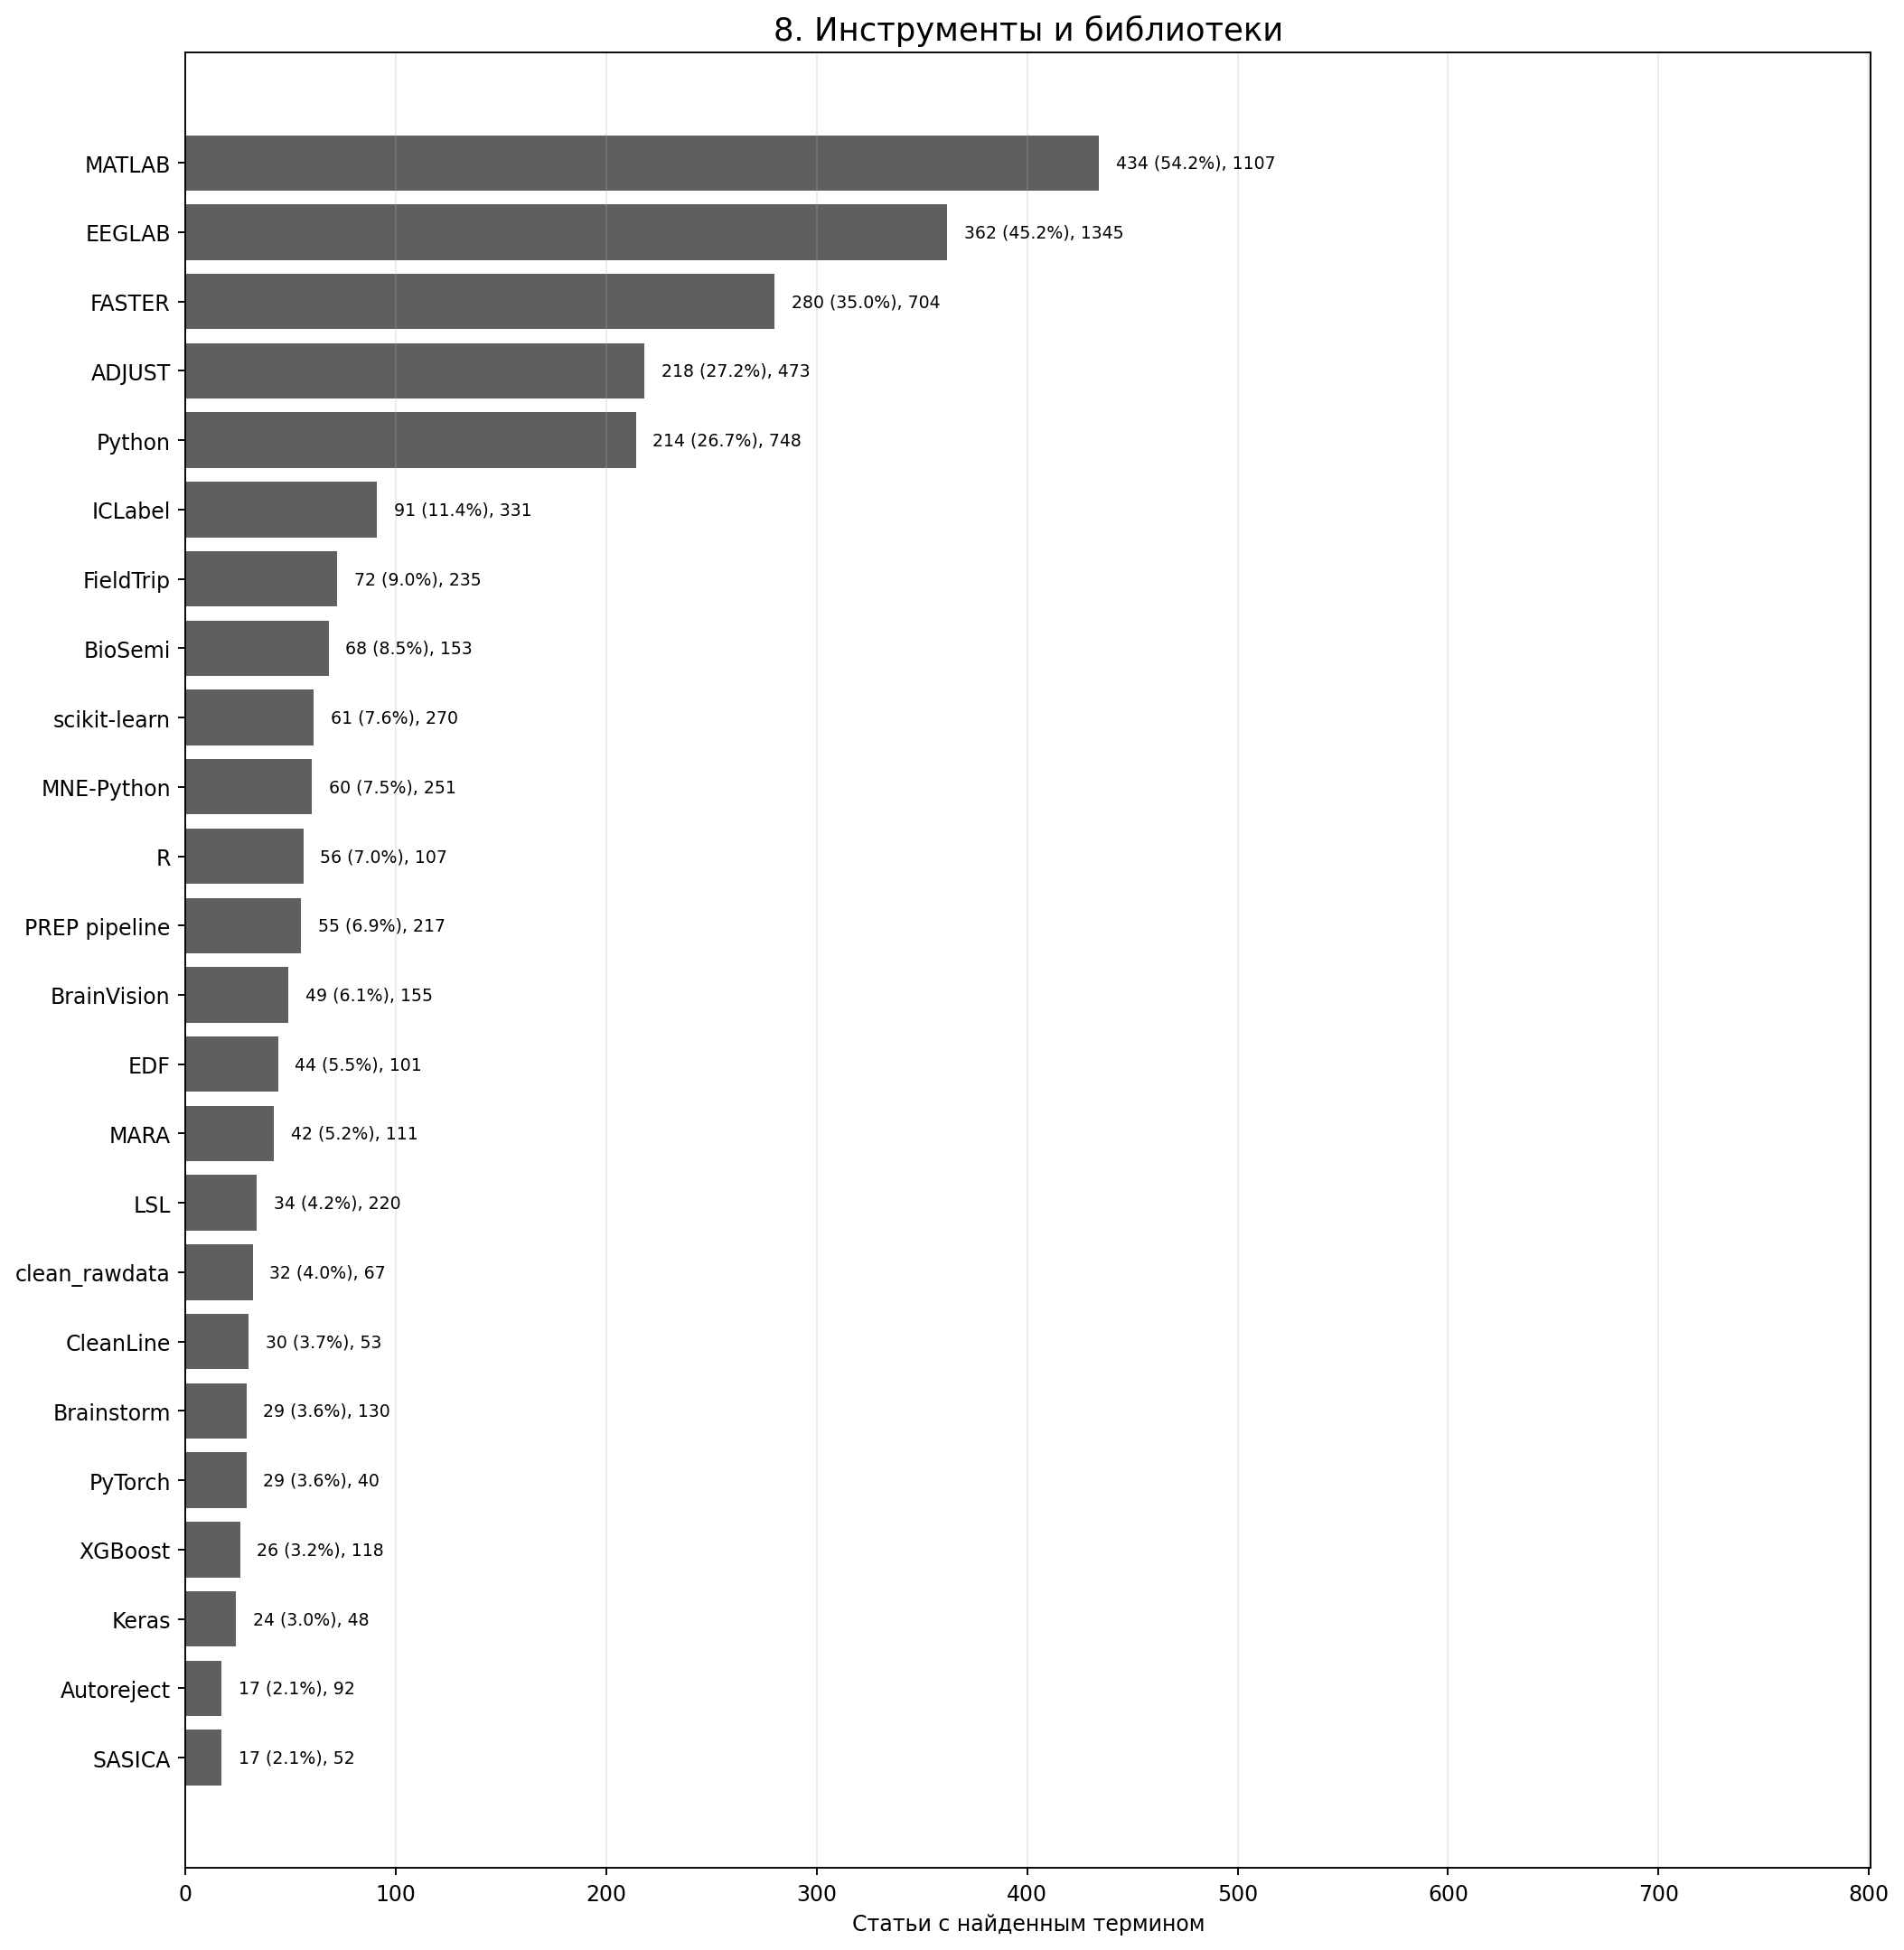

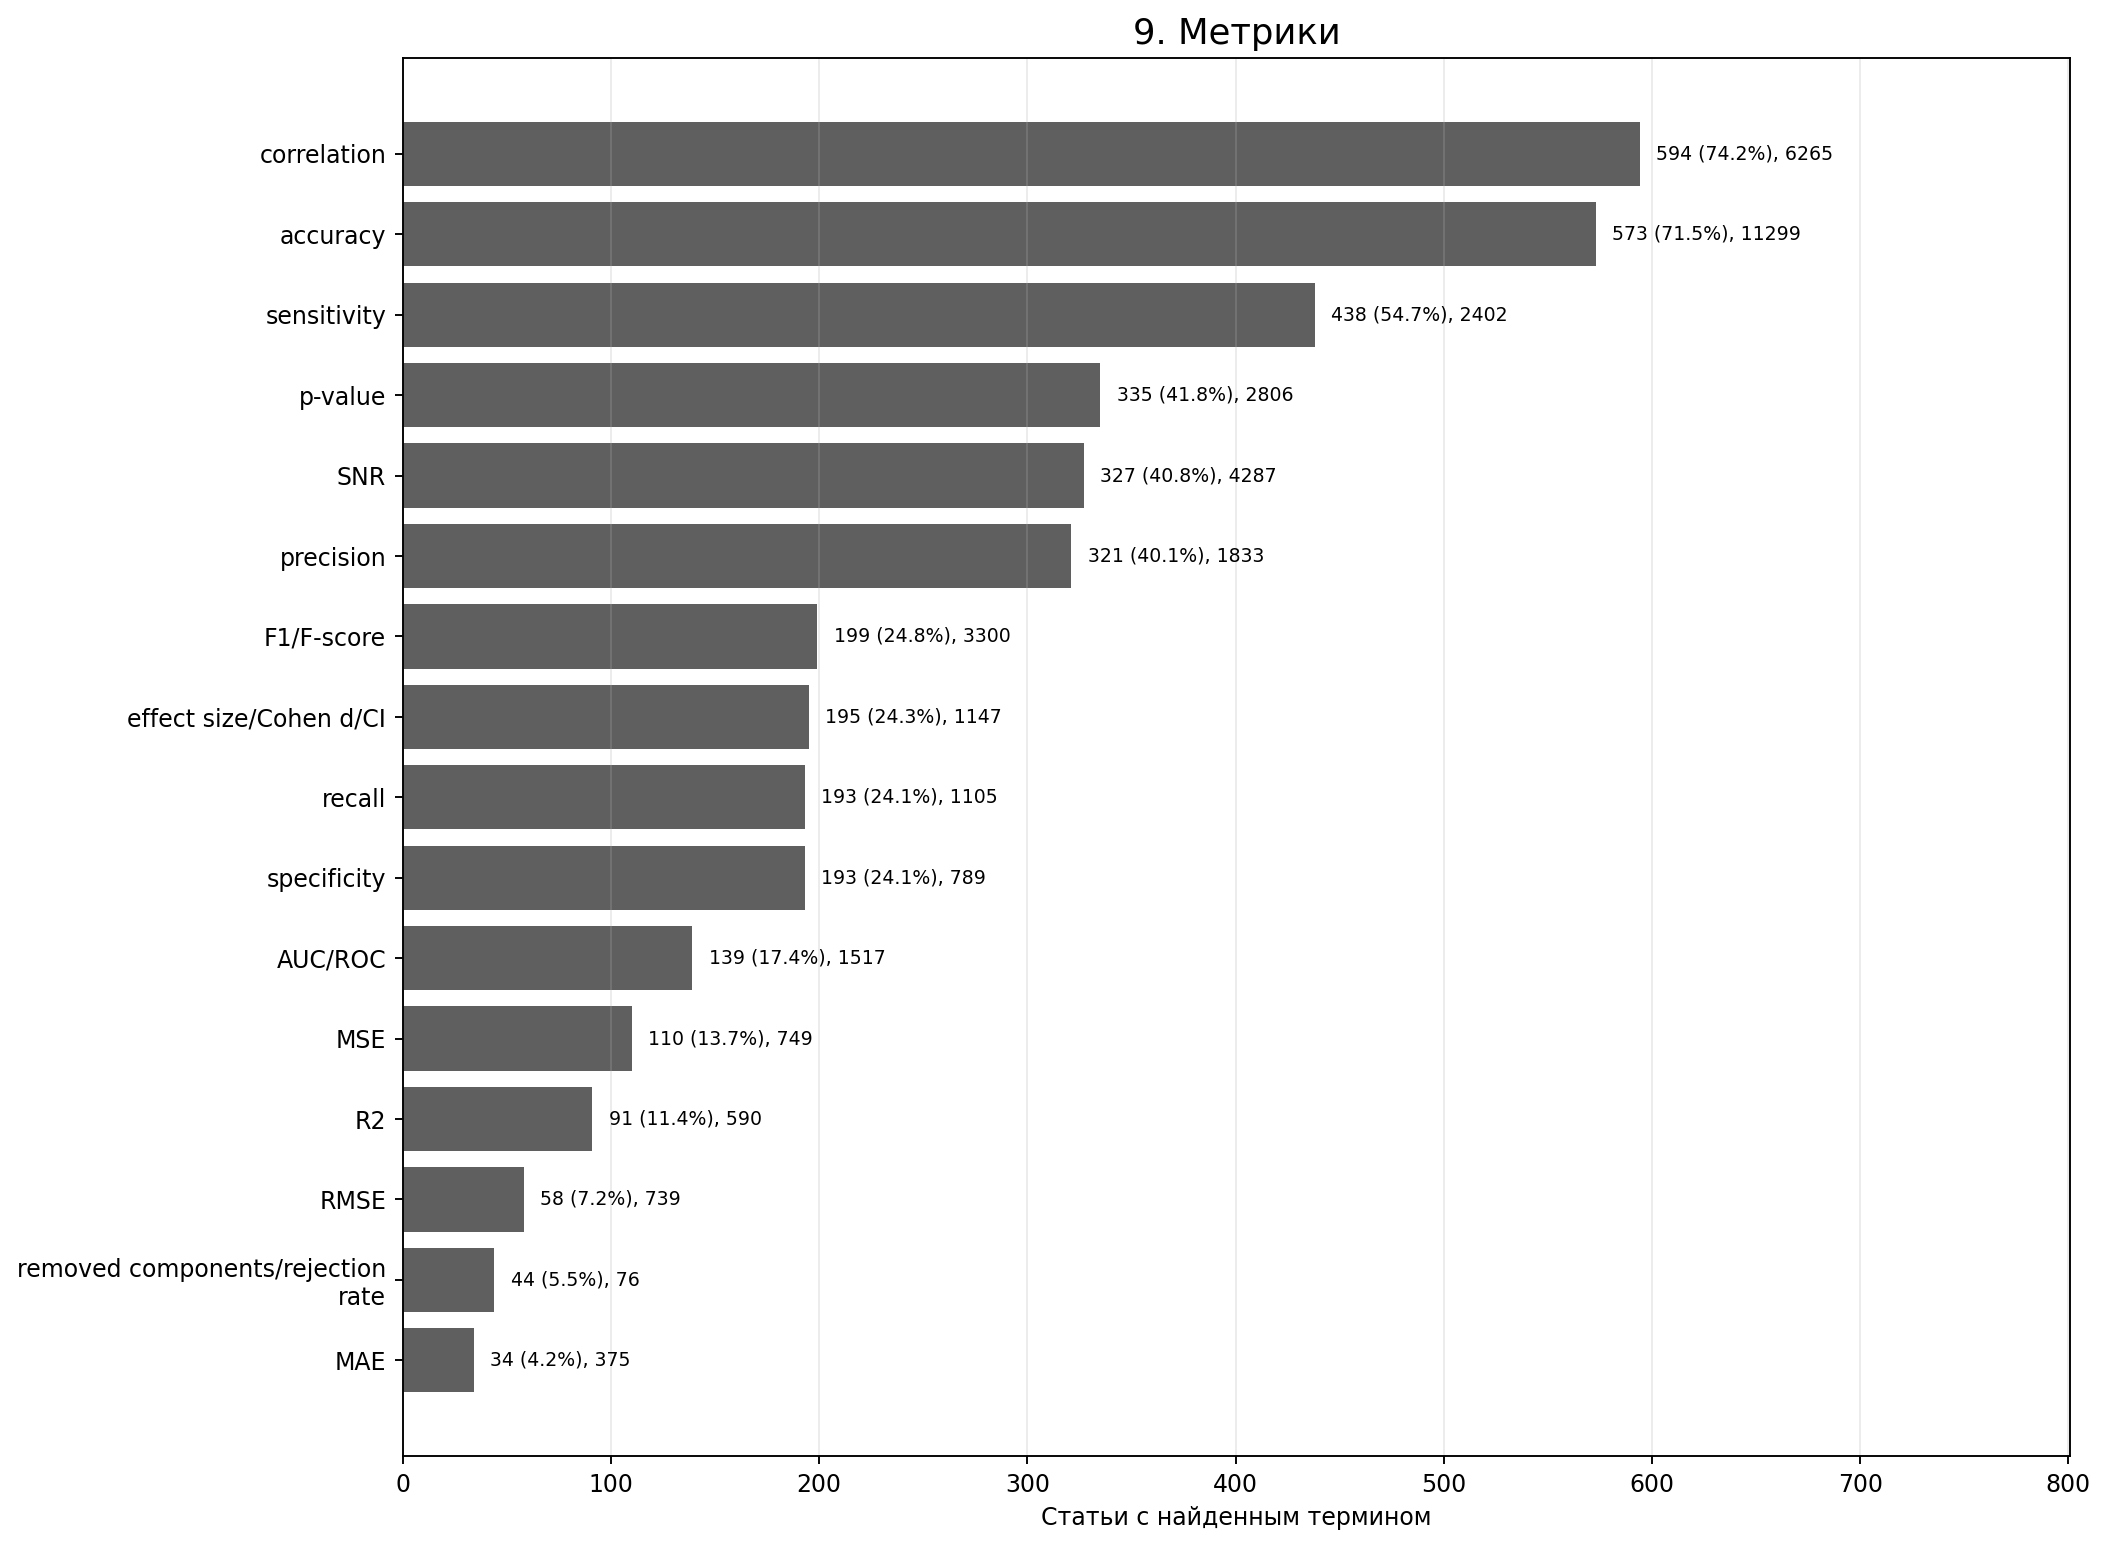

In [6]:
def wrap(text, width=30):
    """Переносит длинную подпись на несколько строк."""
    return "\n".join(textwrap.wrap(str(text), width=width, break_long_words=False))


def draw_bar(level, title, png, min_percent=0):
    """Строит один горизонтальный частотный график."""
    data = freq[freq["level"] == level].copy()  # строки частот только для одного уровня словаря
    data = data[data["percent_articles"] >= min_percent]  # убираем редкие термины на некоторых графиках
    data = data.sort_values(["article_count", "mention_count"], ascending=[False, False])
    data.to_csv(TABLE_DIR / png.replace(".png", ".csv"), index=False, encoding="utf-8-sig")

    fig, ax = plt.subplots(figsize=(12.5, max(5.0, 0.45 * len(data) + 2)), dpi=170)
    ax.barh([wrap(label, 30) for label in data["label"]], data["article_count"], color="#5f5f5f")
    ax.invert_yaxis()
    ax.set_title(title, fontsize=15)
    ax.set_xlabel("Статьи с найденным термином")
    ax.set_xlim(0, total)
    ax.grid(axis="x", alpha=0.25)

    for y, row in enumerate(data.itertuples(index=False)):
        text = f"{row.article_count} ({row.percent_articles:.1f}%), {row.mention_count}"
        ax.text(row.article_count + total * 0.01, y, text, va="center", fontsize=8)

    fig.tight_layout()
    fig.savefig(FREQ_DIR / png, dpi=170, bbox_inches="tight", facecolor="white")
    display(fig)
    plt.close(fig)


graphs = [  # level, заголовок, имя PNG, минимальный процент статей
    ("marker_artifact", "4. Маркер (артефакт)", "04_marker_artifact_frequency.png", 0),
    ("feature", "6. Признаки", "06_feature_frequency.png", 5),
    ("method", "7. Методы и модели", "07_method_model_frequency.png", 10),
    ("tool", "8. Инструменты и библиотеки", "08_tool_library_frequency.png", 2),
    ("metric", "9. Метрики", "10_metric_frequency.png", 2),
]

for level, title, png, min_percent in tqdm(graphs, desc="Частотные графики", unit="график", leave=False):
    draw_bar(level, title, png, min_percent)


## 7. Матрицы


Матрицы:   0%|          | 0/7 [00:00<?, ?матрица/s]

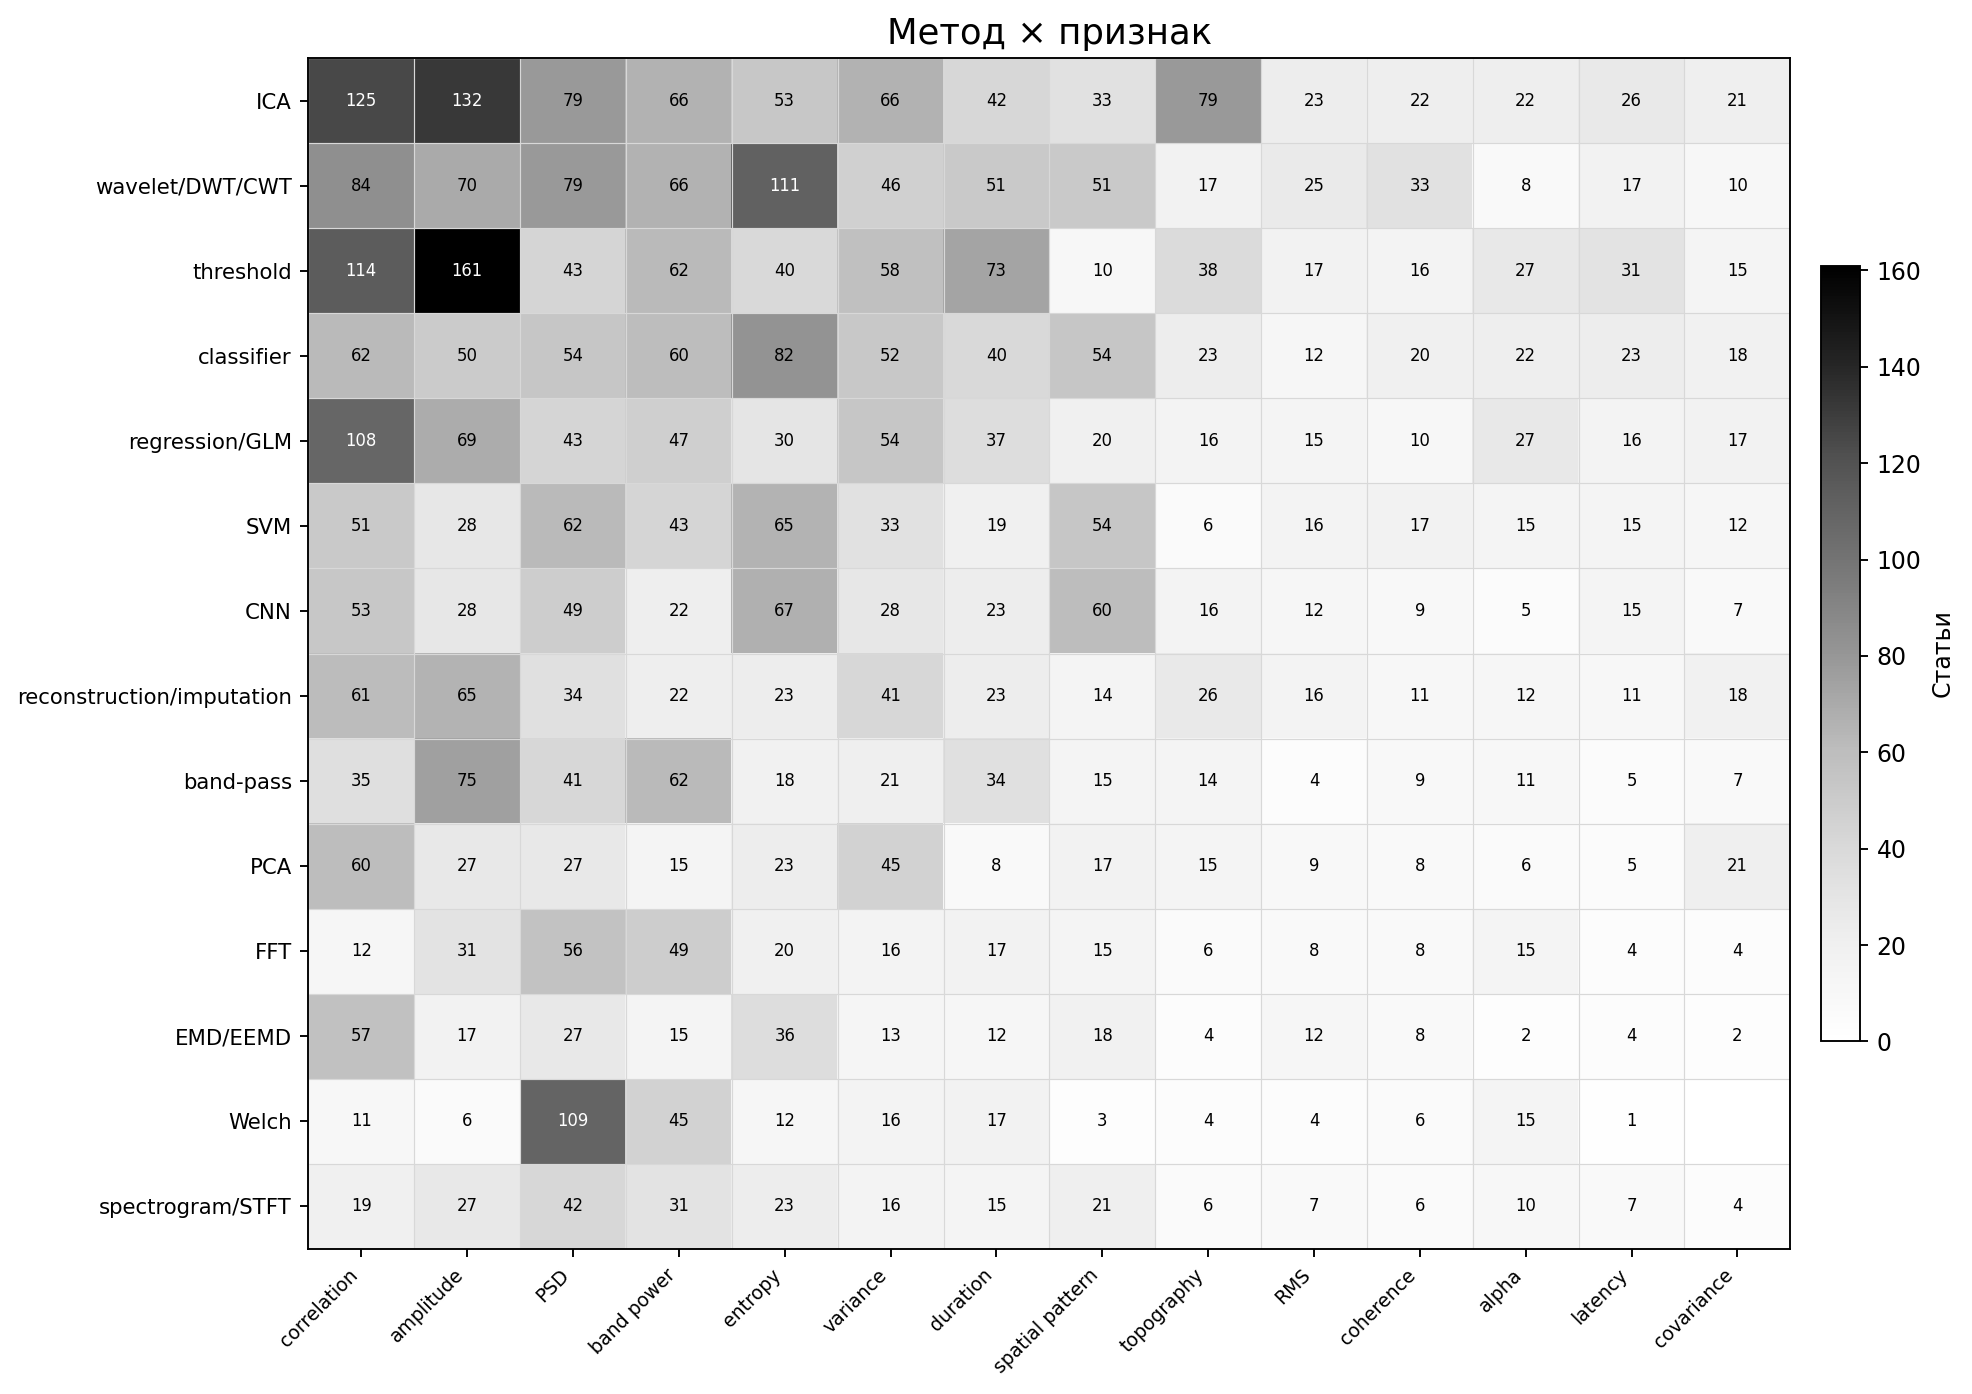

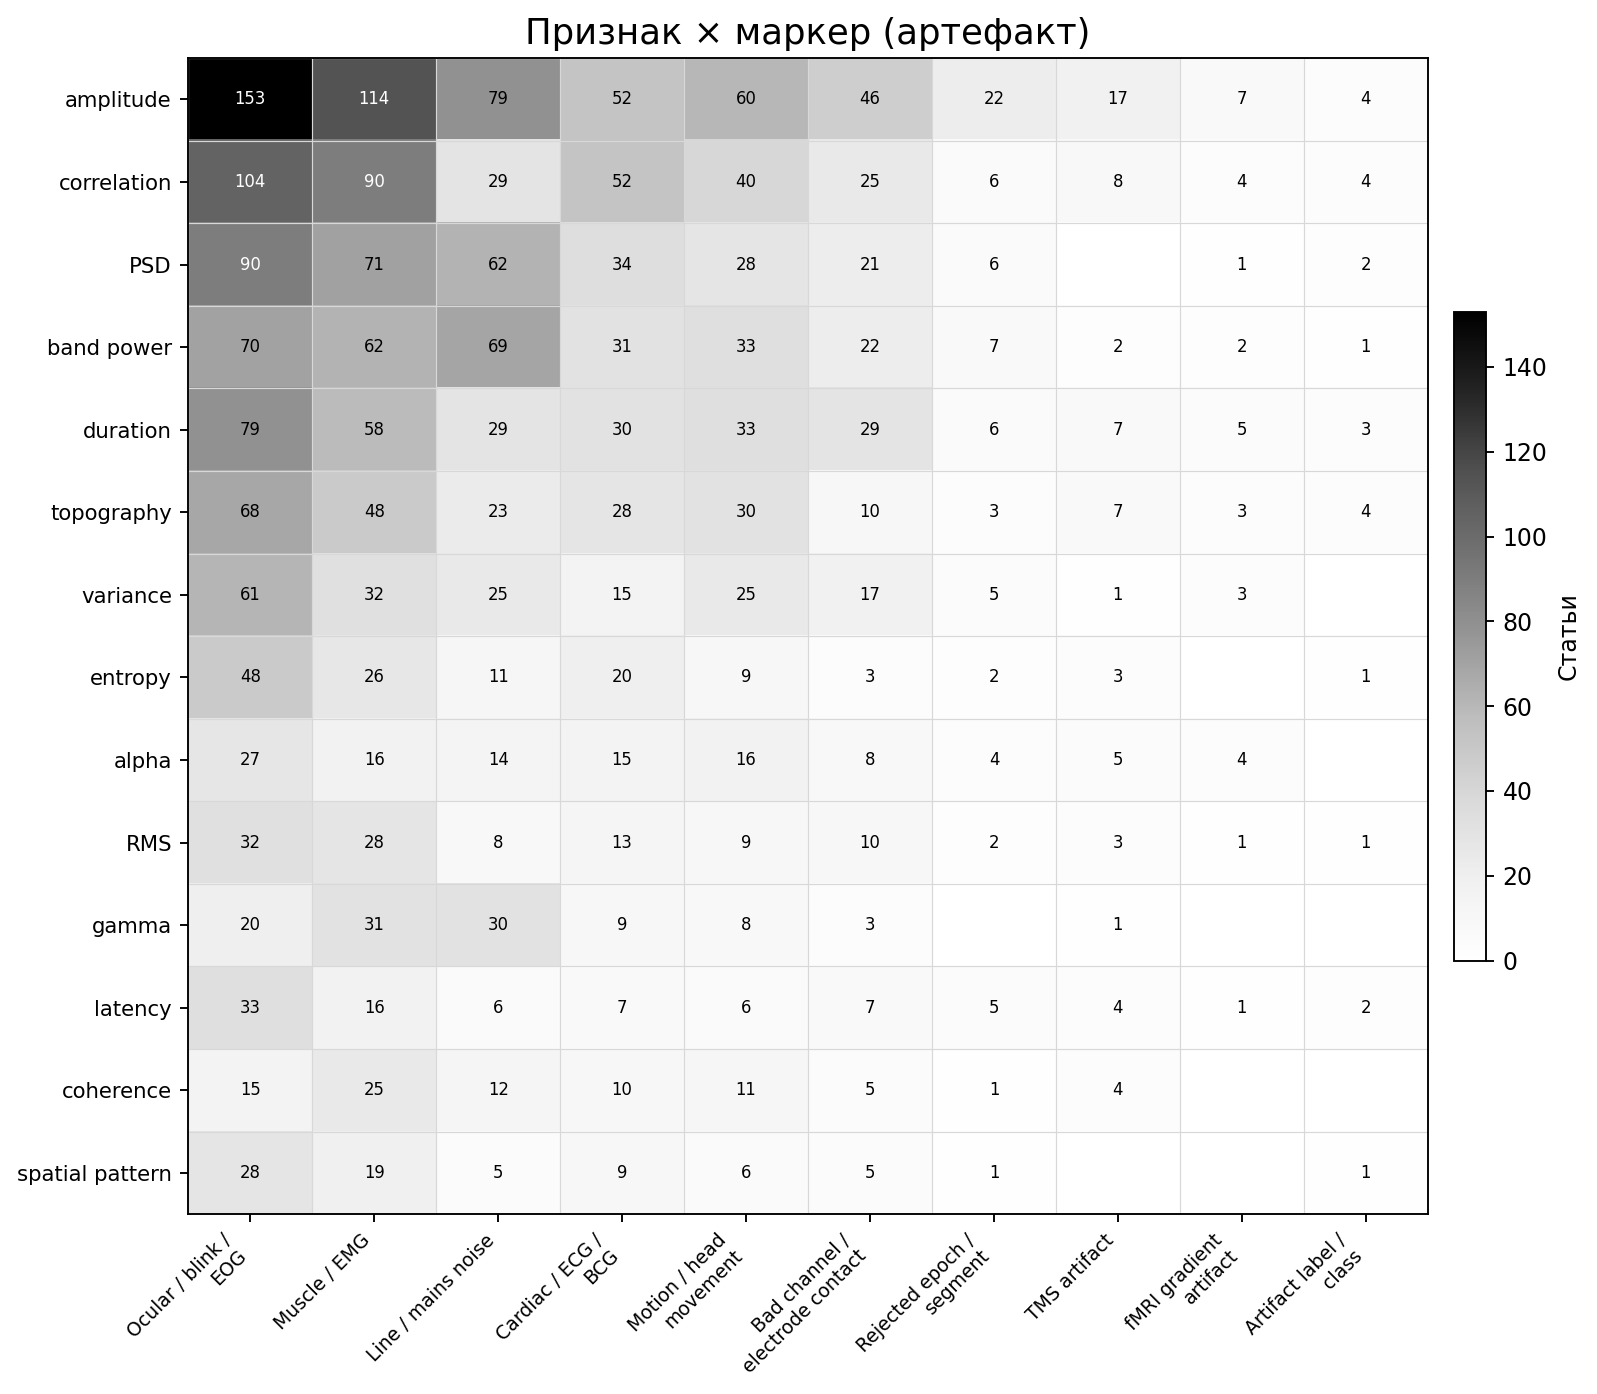

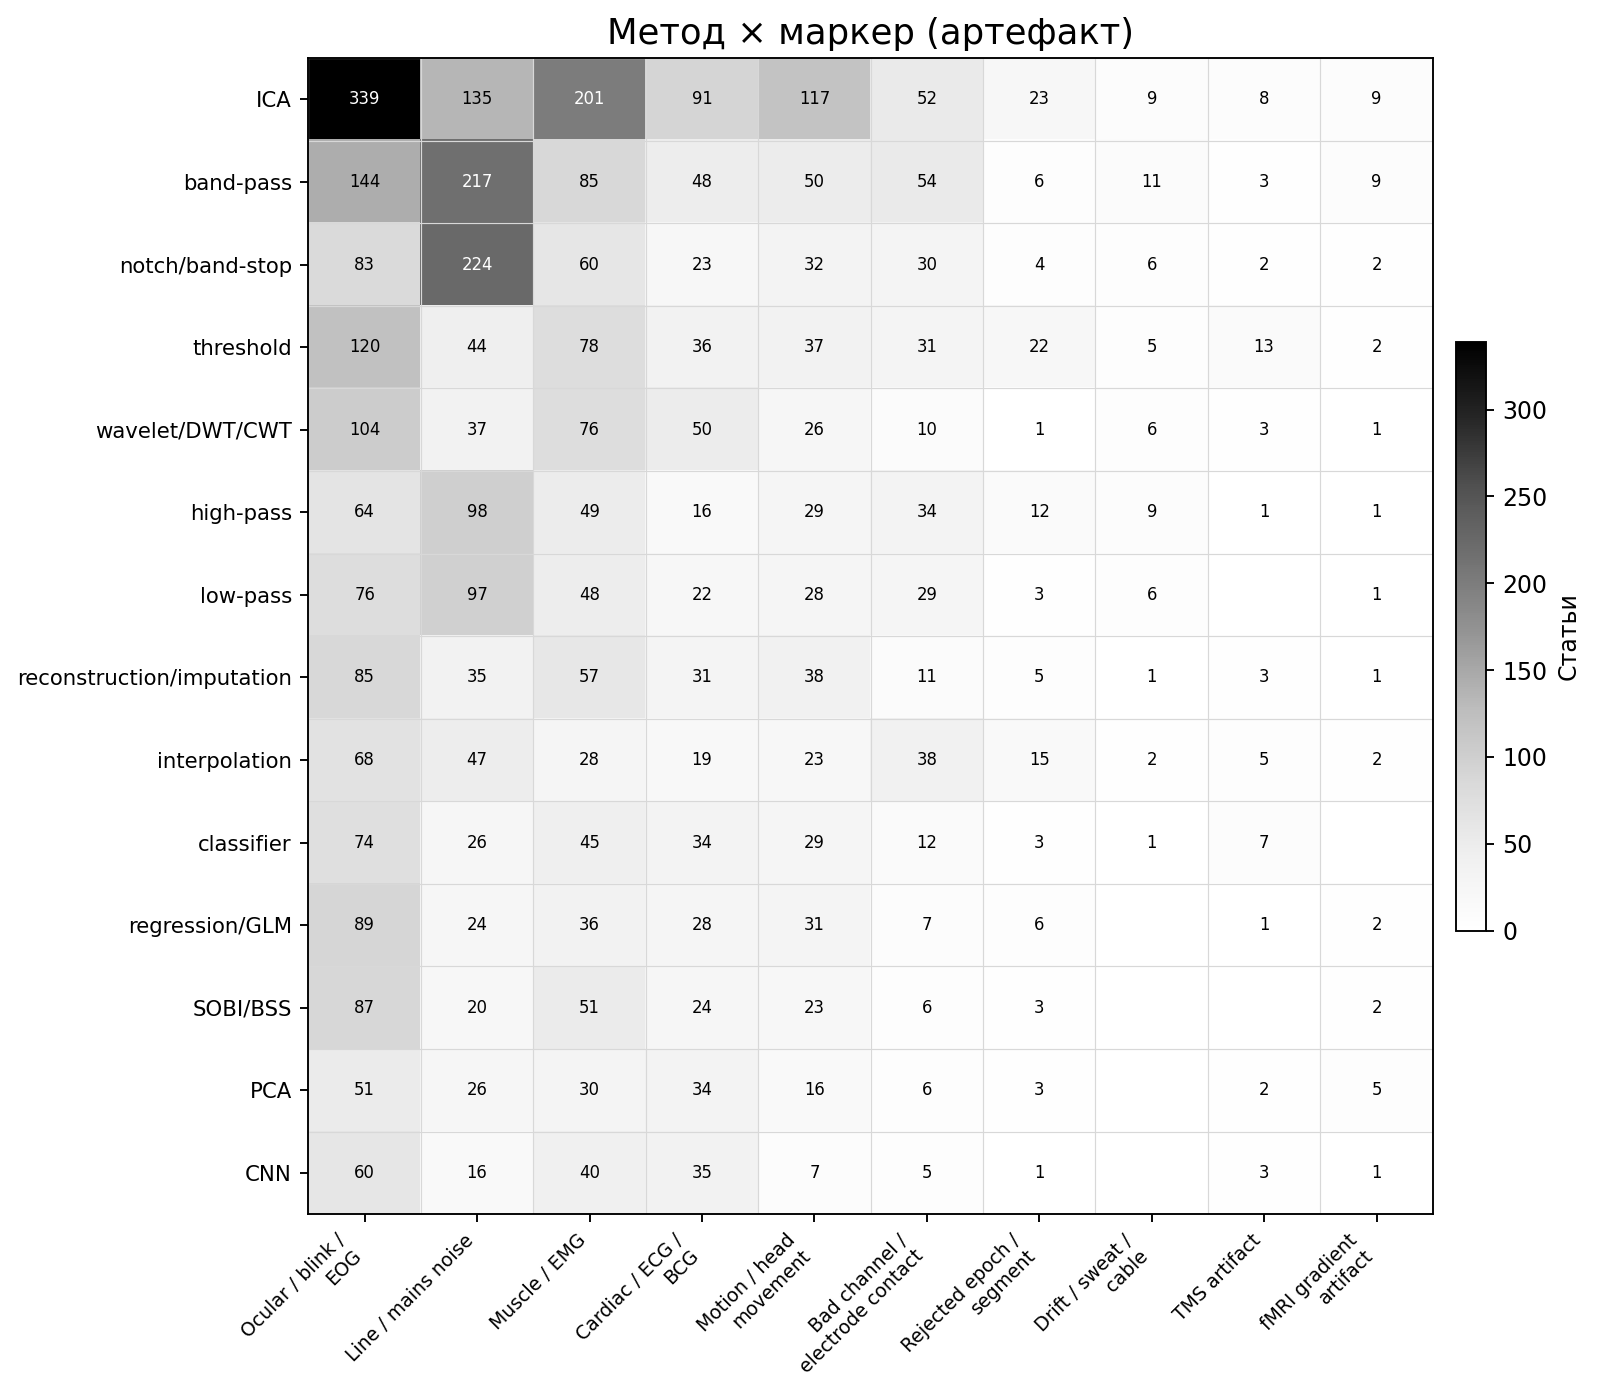

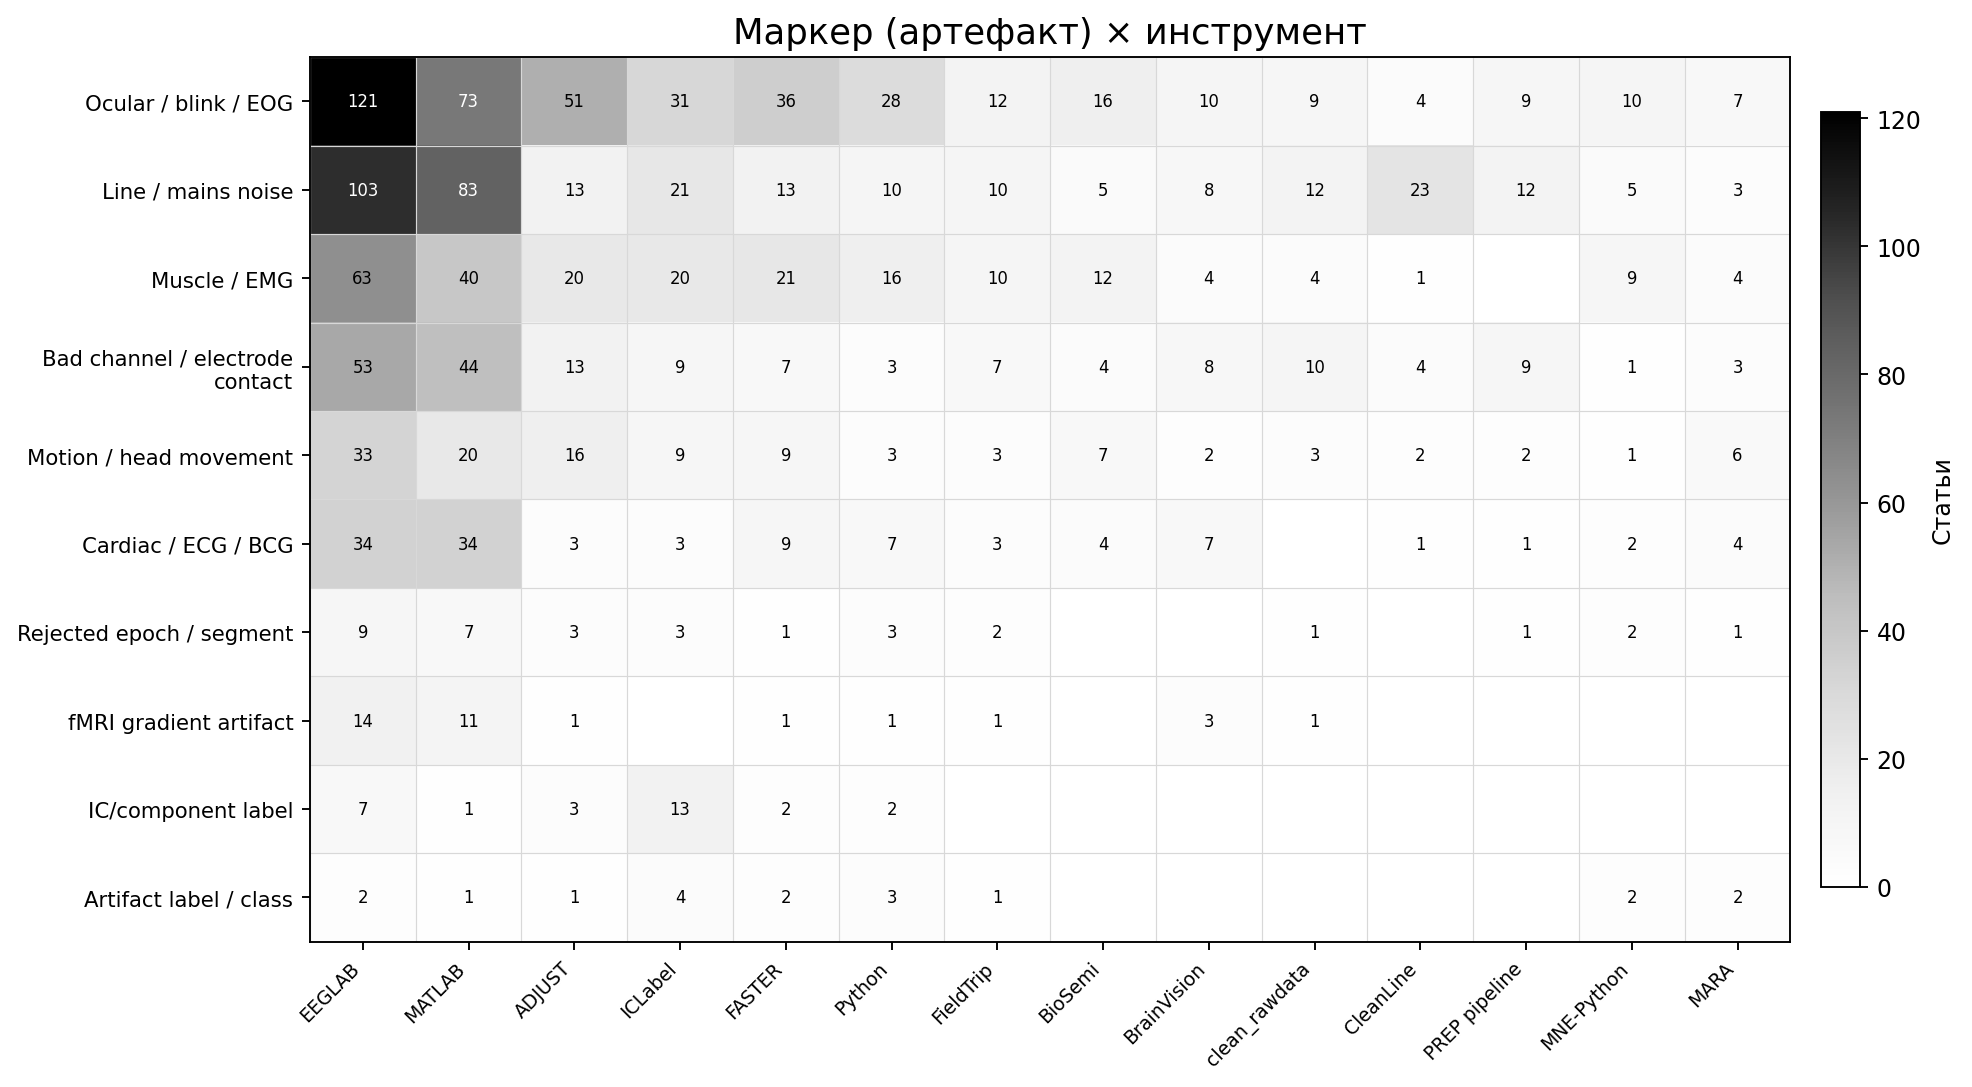

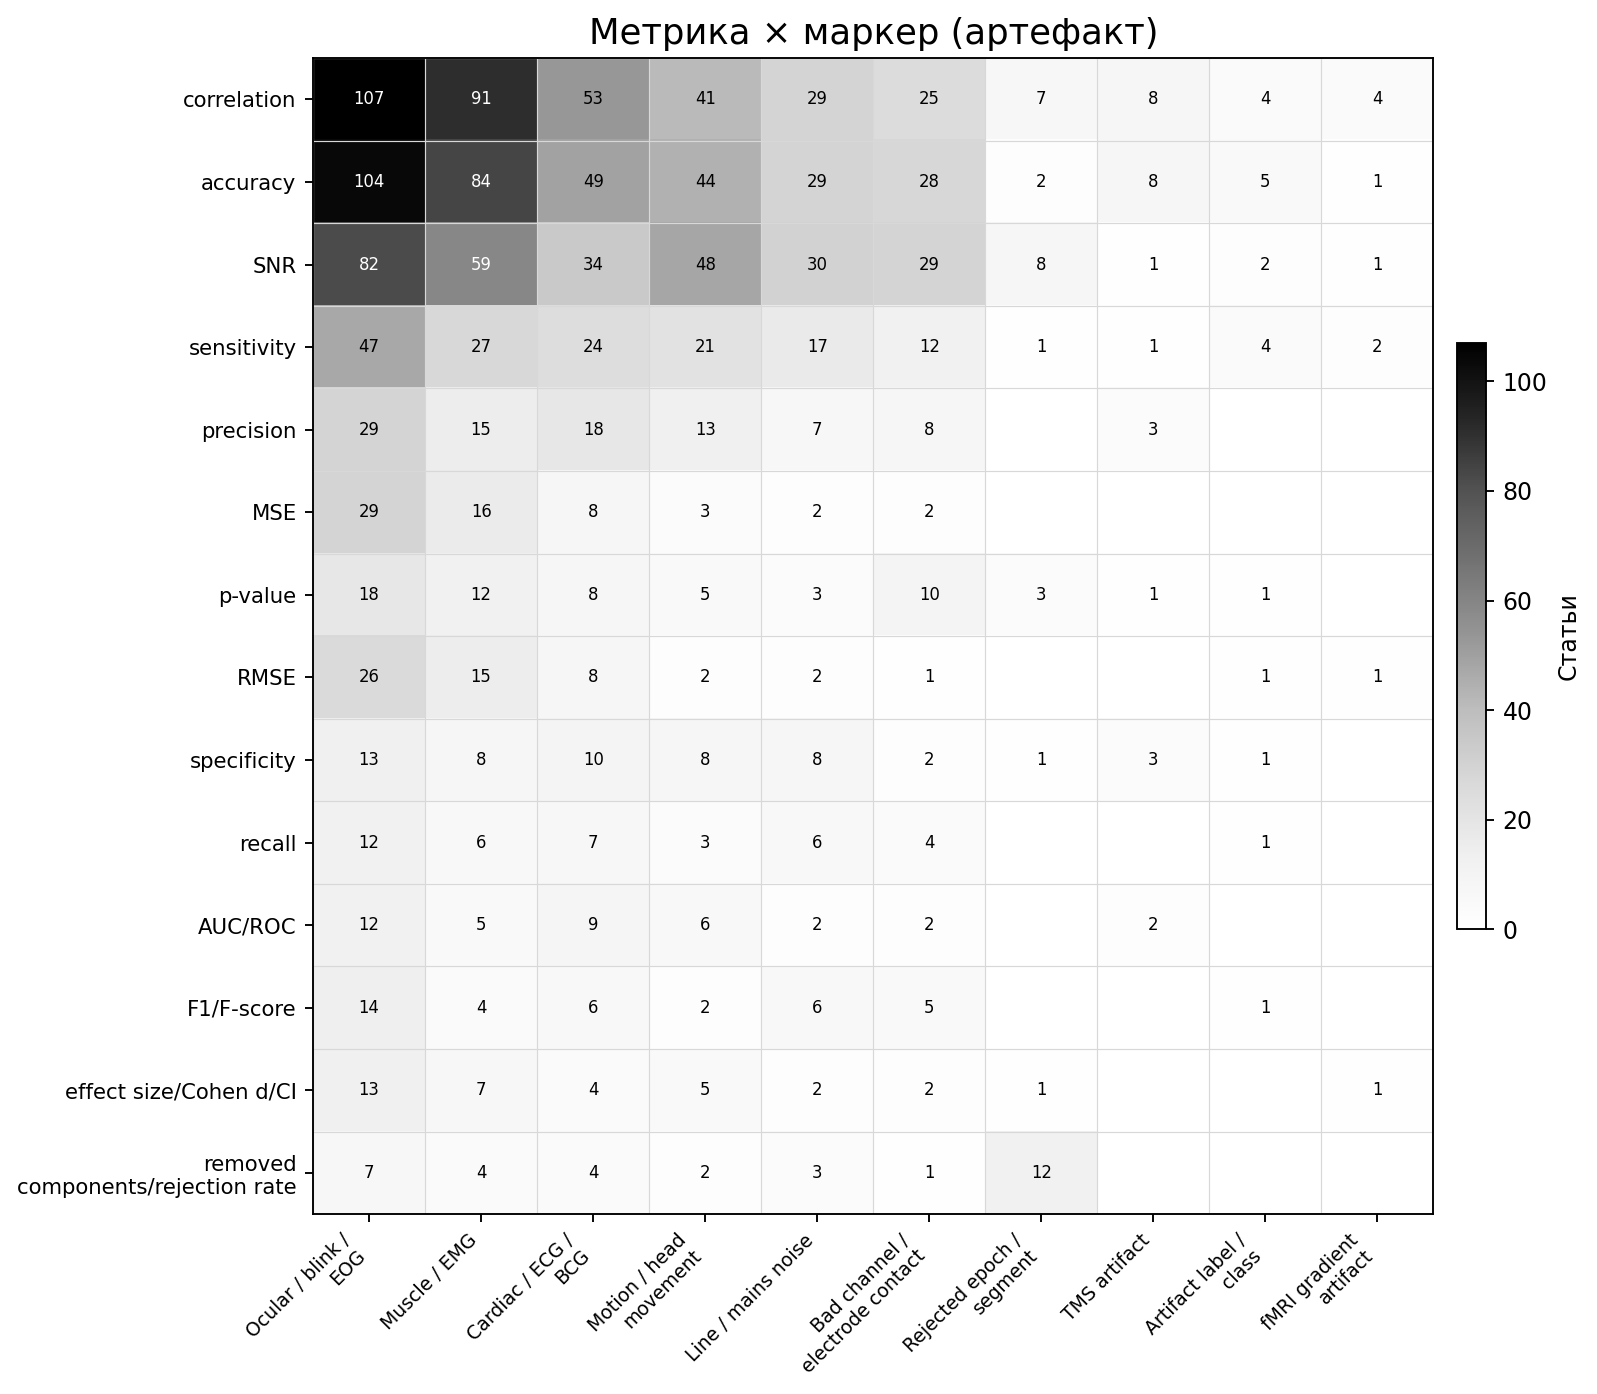

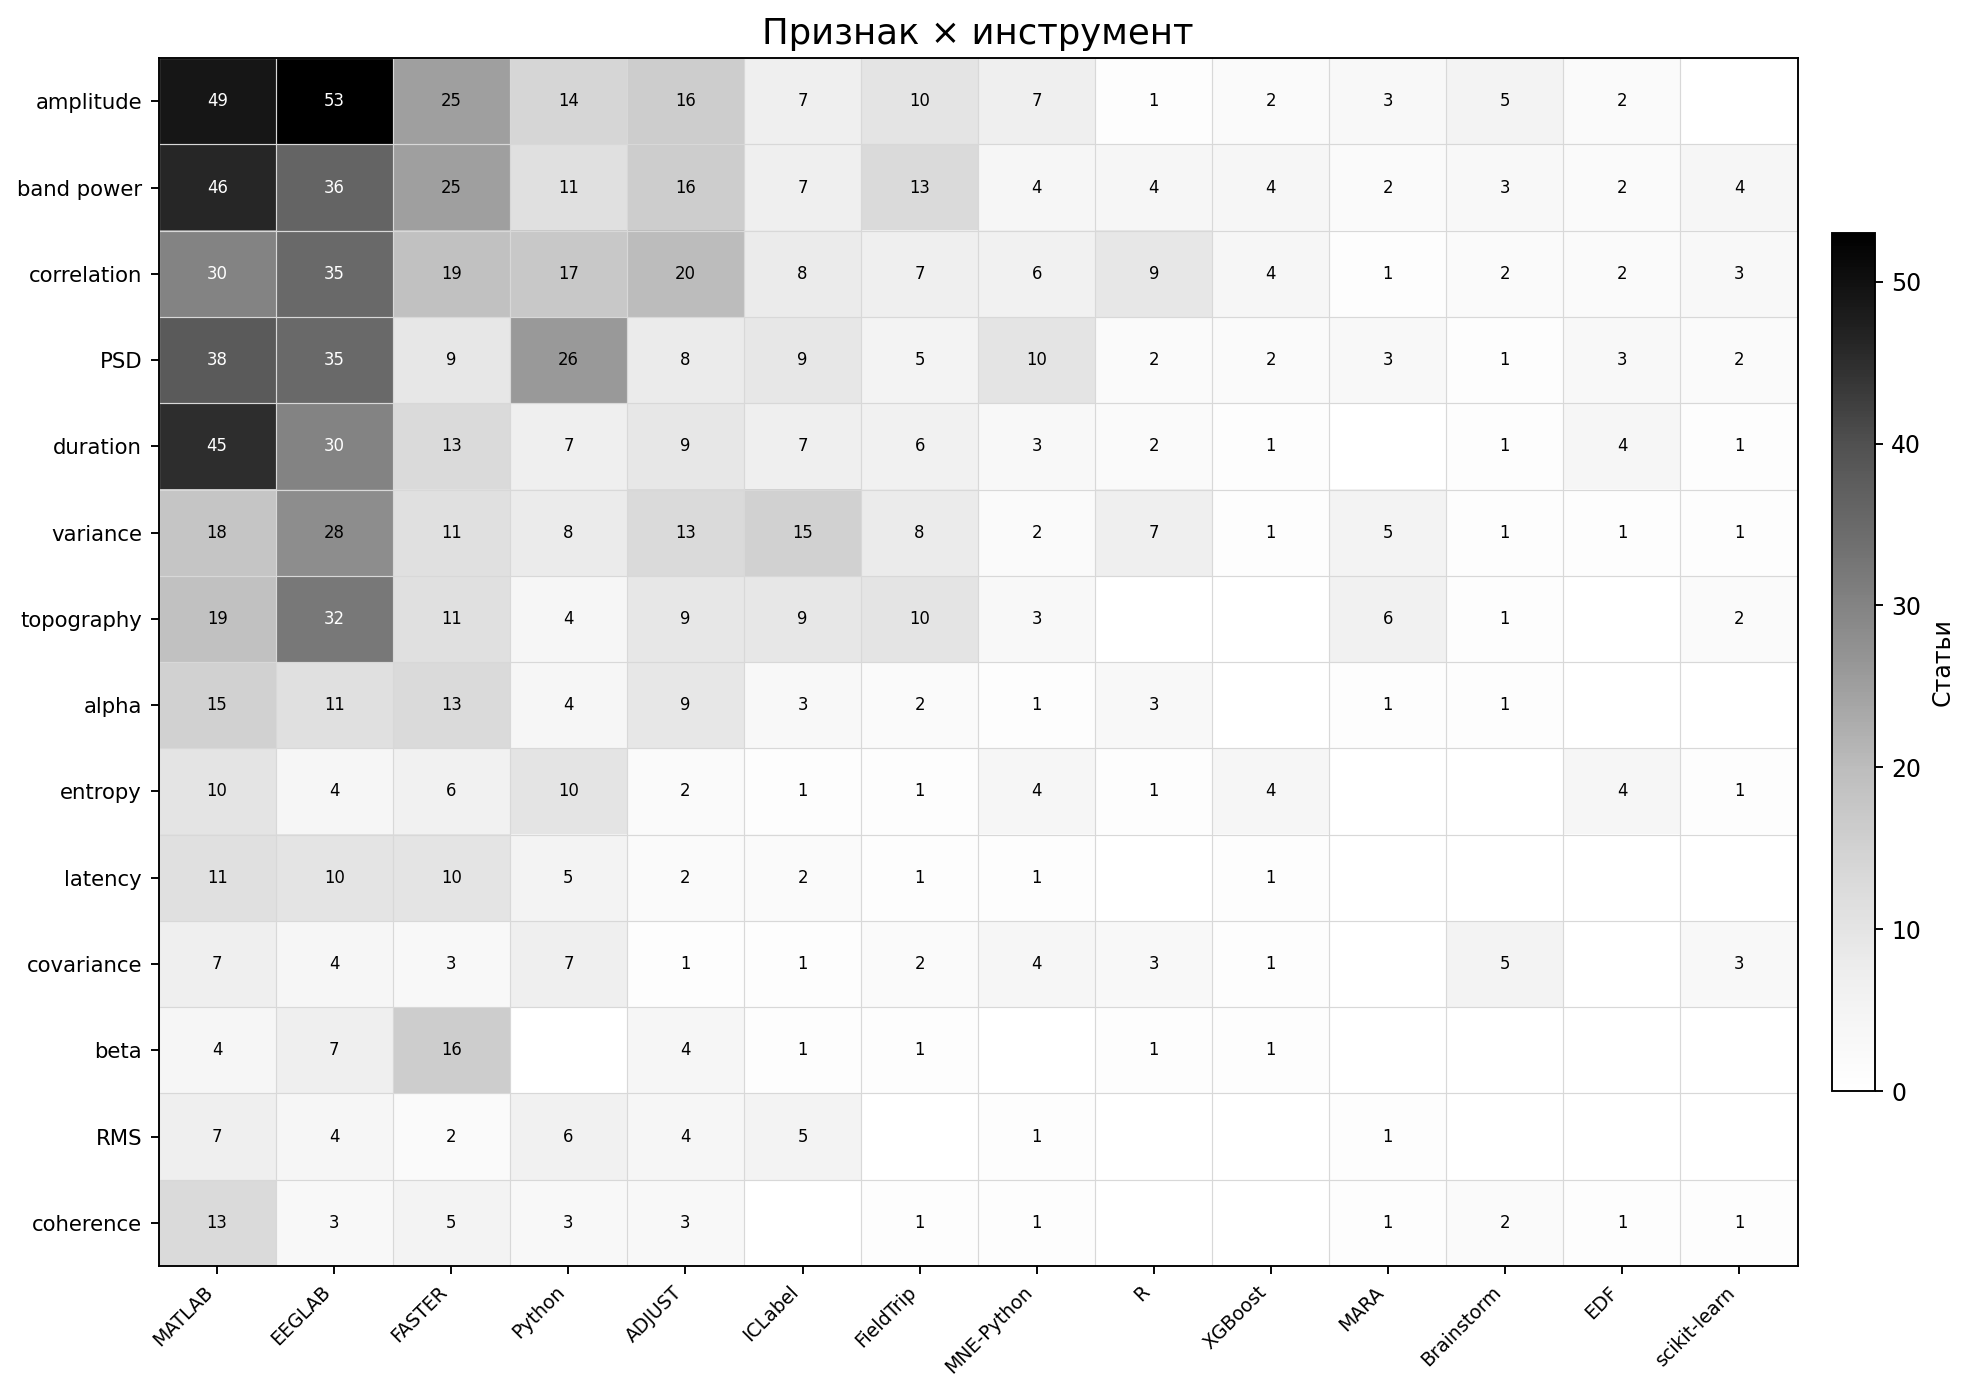

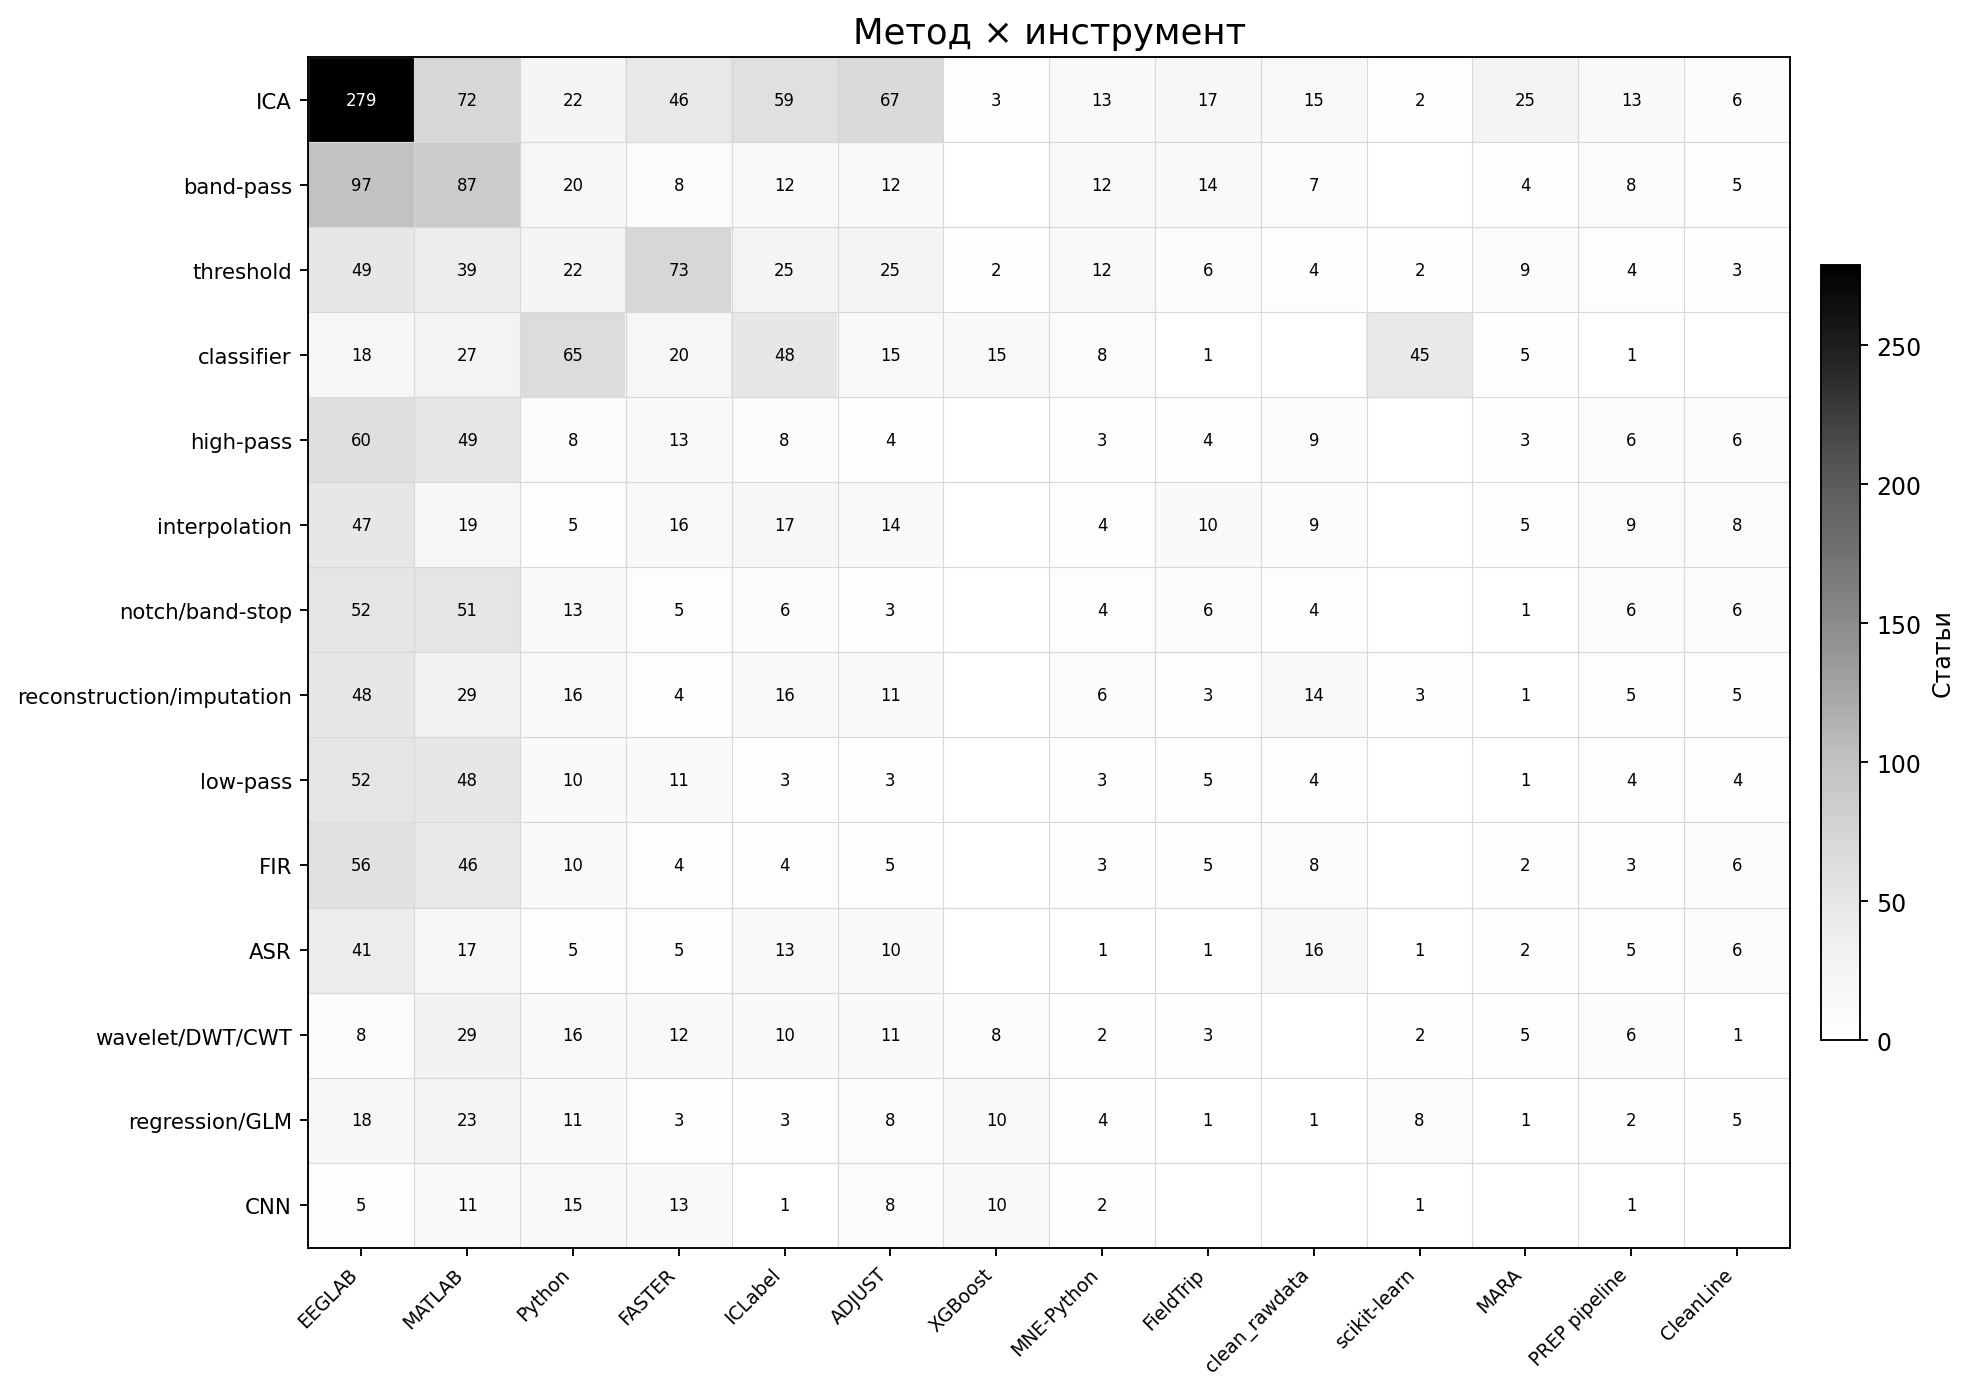

In [7]:
def matrix(row_level, col_level, max_rows=14, max_cols=14):
    """Делает таблицу для одной матрицы и оставляет самые частые строки/столбцы."""
    part = pairs[(pairs["row_level"] == row_level) & (pairs["col_level"] == col_level)]  # нужная связка уровней
    table = part.pivot_table(index="row", columns="col", values="article_count", aggfunc="max", fill_value=0)

    rows = table.sum(axis=1).sort_values(ascending=False).head(max_rows).index  # самые частые строки
    cols = table.sum(axis=0).sort_values(ascending=False).head(max_cols).index  # самые частые столбцы
    return table.loc[rows, cols]


def draw_matrix(table, title, png):
    """Рисует одну тепловую матрицу и сохраняет ее в PNG."""
    table.to_csv(TABLE_DIR / png.replace(".png", ".csv"), encoding="utf-8-sig")

    fig, ax = plt.subplots(
        figsize=(max(9, 0.55 * len(table.columns) + 4), max(5.5, 0.45 * len(table.index) + 2)),
        dpi=170,
    )
    image = ax.imshow(table.values, cmap="Greys", aspect="auto")  # сама черно-белая матрица
    ax.set_title(title, fontsize=15)
    ax.set_xticks(np.arange(len(table.columns)))
    ax.set_yticks(np.arange(len(table.index)))
    ax.set_xticklabels([wrap(label, 18) for label in table.columns], rotation=45, ha="right", fontsize=8)
    ax.set_yticklabels([wrap(label, 26) for label in table.index], fontsize=9)

    max_value = table.values.max()  # максимум нужен, чтобы выбрать цвет числа в ячейке
    for row in range(table.shape[0]):
        for col in range(table.shape[1]):
            value = int(table.iat[row, col])
            if value:
                color = "white" if value > max_value * 0.55 else "black"
                ax.text(col, row, str(value), ha="center", va="center", fontsize=7, color=color)

    ax.set_xticks(np.arange(-0.5, len(table.columns), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(table.index), 1), minor=True)
    ax.grid(which="minor", color="#d8d8d8", linewidth=0.5)
    ax.tick_params(which="minor", bottom=False, left=False)
    fig.colorbar(image, ax=ax, fraction=0.025, pad=0.02).set_label("Статьи")
    fig.tight_layout()
    fig.savefig(MATRIX_DIR / png, dpi=170, bbox_inches="tight", facecolor="white")
    display(fig)
    plt.close(fig)


matrices = [  # строка матрицы, столбец матрицы, заголовок, имя PNG, лимиты строк и столбцов
    ("method", "feature", "Метод × признак", "01_method_by_feature.png", 14, 14),
    ("feature", "marker_artifact", "Признак × маркер (артефакт)", "02_feature_by_marker_artifact.png", 14, 10),
    ("method", "marker_artifact", "Метод × маркер (артефакт)", "03_method_by_marker_artifact.png", 14, 10),
    ("marker_artifact", "tool", "Маркер (артефакт) × инструмент", "04_marker_artifact_by_tool.png", 10, 14),
    ("metric", "marker_artifact", "Метрика × маркер (артефакт)", "05_metric_by_marker_artifact.png", 14, 10),
    ("feature", "tool", "Признак × инструмент", "06_feature_by_tool.png", 14, 14),
    ("method", "tool", "Метод × инструмент", "07_method_by_tool.png", 14, 14),
]

for row_level, col_level, title, png, max_rows, max_cols in tqdm(matrices, desc="Матрицы", unit="матрица", leave=False):
    table = matrix(row_level, col_level, max_rows, max_cols)  # таблица чисел для одной матрицы
    draw_matrix(table, title, png)
